# Predicting which Hogwarts house Harry Potter Characters belong to

In [1]:
import pandas as pd
import numpy as np

# for classification
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# for (re)clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Download & Inspect the data

In [2]:
# Load the CSV file for the training dataset
data = pd.read_csv('harry_potter_1000_students.csv')
df = pd.DataFrame(data)

df

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw
...,...,...,...,...,...,...,...,...,...,...
995,Half-blood,7,10,3,7,1,1,3,8,Ravenclaw
996,Pure-blood,7,3,2,7,8,6,7,7,Slytherin
997,Half-blood,5,10,5,3,3,5,7,10,Ravenclaw
998,Half-blood,5,6,10,4,4,6,2,4,Hufflepuff


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Blood Status         1000 non-null   object
 1   Bravery              1000 non-null   int64 
 2   Intelligence         1000 non-null   int64 
 3   Loyalty              1000 non-null   int64 
 4   Ambition             1000 non-null   int64 
 5   Dark Arts Knowledge  1000 non-null   int64 
 6   Quidditch Skills     1000 non-null   int64 
 7   Dueling Skills       1000 non-null   int64 
 8   Creativity           1000 non-null   int64 
 9   House                1000 non-null   object
dtypes: int64(8), object(2)
memory usage: 78.3+ KB


In [4]:
# Check if there are any missing values in the DataFrame
has_missing = data.isnull().values.any()
print("Are there any missing values?", has_missing)


# Only show columns with missing values
df.isnull().sum()[df.isnull().sum() > 0]


Are there any missing values? False


Series([], dtype: int64)

In [5]:
numeric_cols = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 
                'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills', 'Creativity']

# Find any out-of-range values
for col in numeric_cols:
    out_of_range = df[(df[col] < 0) | (df[col] > 10)]
    if len(out_of_range) > 0:
        print(f"{col}: {len(out_of_range)} values out of range")
        print(out_of_range[[col]].head())
    else:
        print(f"{col}: All values in range ✓")

Bravery: All values in range ✓
Intelligence: All values in range ✓
Loyalty: All values in range ✓
Ambition: All values in range ✓
Dark Arts Knowledge: All values in range ✓
Quidditch Skills: All values in range ✓
Dueling Skills: All values in range ✓
Creativity: All values in range ✓


In [6]:
# Check if there are non purebloods in Slytherin
non_pureblood_slytherin = df[(df['Blood Status'].isin(['Muggle-born', 'Half-blood'])) & 
                              (df['House'] == 'Slytherin')]
print(f"Non-purebloods in Slytherin: {len(non_pureblood_slytherin)}")

slytherin = df[df['House'] == 'Slytherin']
print(f"Ratio of non purebloods in slytherin: {len(non_pureblood_slytherin)/len(slytherin)}")
print('This is strange and not correct according to the lore.')

Non-purebloods in Slytherin: 177
Ratio of non purebloods in slytherin: 0.6679245283018868
This is strange and not correct according to the lore.


In [7]:
len(df[df['House'] == 'Slytherin'])

265

## Preparing dataset for classification

### using the whole dataset

In [10]:
# Prepare features and target
# Encode Blood Status (categorical feature)
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

# Select features (all numeric columns except House)
feature_cols = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                'Dueling Skills', 'Creativity']

X = df[feature_cols].values
y = df['House'].values


In [9]:
df['Blood Status Encoded'].unique()

array([0, 1, 2])

### politically-correct-only attributes (according to the lore)

In [57]:
# Prepare features and target
# Encode Blood Status (categorical feature)
le = LabelEncoder()
df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

# Select features (all numeric columns except House)
feature_cols = ['Bravery', 'Intelligence', 'Loyalty', 
                'Ambition']

X = df[feature_cols].values
y = df['House'].values


### class distribution BEFORE split

In [24]:
print("\n" + "="*60)
print("HOUSE DISTRIBUTION IN ORIGINAL DATASET")
print("="*60)

unique_orig, counts_orig = np.unique(y, return_counts=True)
for house, count in zip(unique_orig, counts_orig):
    print(f"  {house:12s}: {count:3d} ({count/len(y)*100:.1f}%)")


HOUSE DISTRIBUTION IN ORIGINAL DATASET
  Gryffindor  : 226 (22.6%)
  Hufflepuff  : 251 (25.1%)
  Ravenclaw   : 258 (25.8%)
  Slytherin   : 265 (26.5%)


# Splitting data into train-test-split

In [25]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Base Classifier

In [26]:
print("\n" + "="*60)
print("HOUSE DISTRIBUTION AFTER TRAIN-TEST SPLIT")
print("="*60)

# Show class distribution
print("\nTraining set distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for house, count in zip(unique, counts):
    print(f"  {house:12s}: {count:3d} ({count/len(y_train)*100:.1f}%)")

print("\nTest set distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for house, count in zip(unique_test, counts_test):
    print(f"  {house:12s}: {count:3d} ({count/len(y_test)*100:.1f}%)")

# Create and train majority class classifier
print("\n" + "="*60)
print("MAJORITY CLASS CLASSIFIER")
print("="*60)

majority_clf = DummyClassifier(strategy='most_frequent', random_state=42)
majority_clf.fit(X_train, y_train)

# Make predictions
y_pred = majority_clf.predict(X_test)

# Find the majority class
majority_house = unique[np.argmax(counts)]
print(f"\nMajority House: {majority_house}")
print(f"Strategy: Always predict '{majority_house}'")

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")



HOUSE DISTRIBUTION AFTER TRAIN-TEST SPLIT

Training set distribution:
  Gryffindor  : 158 (22.6%)
  Hufflepuff  : 176 (25.1%)
  Ravenclaw   : 181 (25.9%)
  Slytherin   : 185 (26.4%)

Test set distribution:
  Gryffindor  :  68 (22.7%)
  Hufflepuff  :  75 (25.0%)
  Ravenclaw   :  77 (25.7%)
  Slytherin   :  80 (26.7%)

MAJORITY CLASS CLASSIFIER

Majority House: Slytherin
Strategy: Always predict 'Slytherin'

Accuracy: 0.2667 (26.67%)


# Decision Tree

In [27]:
# Train Decision Tree Classifier with Hyperparameter Tuning
print("\n" + "="*60)
print("DECISION TREE WITH HYPERPARAMETER TUNING")
print("="*60)

# Define parameters for Decision Tree
dt_param_dist = {
'max_depth': [3, 5, 7, None],
'min_samples_split': [2, 5, 10, 15, 20],
'min_samples_leaf': [1, 2, 4, 8, 10],
'criterion': ['gini', 'entropy'],
'splitter': ['best', 'random'],
'max_features': ['sqrt', 'log2', None]
}

print("\nSearching for best hyperparameters for Decision Tree...")
print("Parameter space:")
for param, values in dt_param_dist.items():
    print(f"  {param}: {values}")

# Create base Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)

# Perform RandomizedSearchCV
dt_random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=dt_param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

dt_random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in dt_random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {dt_random_search.best_score_:.4f} ({dt_random_search.best_score_*100:.2f}%)")

# Use the best model
dt_clf = dt_random_search.best_estimator_

# Make predictions
y_pred_dt = dt_clf.predict(X_test)

# Evaluate Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Test Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
print("-"*60)
houses = sorted(np.unique(y))
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=houses)
print(f"\n{'':12s}", end='')
for h in houses:
    print(f"{h:12s}", end='')
print()
for i, h in enumerate(houses):
    print(f"{h:12s}", end='')
    for j in range(len(houses)):
        print(f"{cm_dt[i,j]:12d}", end='')
    print()

# Feature importance for Decision Tree
print("\n" + "-"*60)
print("Decision Tree Feature Importance:")
print("-"*60)
feature_names = feature_cols
dt_importances = dt_clf.feature_importances_
dt_indices = np.argsort(dt_importances)[::-1]

for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[dt_indices[i]]:15s}: {dt_importances[dt_indices[i]]:.4f}")



DECISION TREE WITH HYPERPARAMETER TUNING

Searching for best hyperparameters for Decision Tree...
Parameter space:
  max_depth: [3, 5, 7, None]
  min_samples_split: [2, 5, 10, 15, 20]
  min_samples_leaf: [1, 2, 4, 8, 10]
  criterion: ['gini', 'entropy']
  splitter: ['best', 'random']
  max_features: ['sqrt', 'log2', None]
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters found:
  splitter: best
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: None
  max_depth: 5
  criterion: entropy

Best cross-validation score: 0.9843 (98.43%)

Decision Tree Test Accuracy: 0.9800 (98.00%)

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

  Gryffindor       1.00      0.99      0.99        68
  Hufflepuff       0.93      1.00      0.96        75
   Ravenclaw       1.00      0.94      0.97        77
   Slytherin    

# Random Forest

In [28]:
# Train Random Forest Classifier
print("\n" + "="*60)
print("RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*60)

# Define parameters for RandomizedSearchCV
param_dist = {
'n_estimators': [50, 100, 200, 300, 500],
'max_depth': [3, 5, None],
'min_samples_split': [2, 5, 10, 15],
'min_samples_leaf': [1, 2, 4, 8],
'max_features': ['sqrt', 'log2', None],
'bootstrap': [True, False],
'criterion': ['gini', 'entropy']
}

print("\nSearching for best hyperparameters...")
print("Parameter space:")
for param, values in param_dist.items():
    print(f"  {param}: {values}")

# Create base Random Forest
rf_base = RandomForestClassifier(random_state=42)

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,  # Number of random combinations to try
    cv=3,  # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,  # Use all available cores
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {random_search.best_score_:.4f} ({random_search.best_score_*100:.2f}%)")

# Use the best model
rf_clf = random_search.best_estimator_

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

print("Confusion Matrix:")
print("-"*60)
houses = sorted(np.unique(y))
cm_dt = confusion_matrix(y_test, y_pred_rf, labels=houses)
print(f"\n{'':12s}", end='')
for h in houses:
    print(f"{h:12s}", end='')
print()
for i, h in enumerate(houses):
    print(f"{h:12s}", end='')
    for j in range(len(houses)):
        print(f"{cm_dt[i,j]:12d}", end='')
    print()



# Feature importance
print("\n" + "-"*60)
print("Feature Importance:")
print("-"*60)
feature_names = feature_cols
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]:15s}: {importances[indices[i]]:.4f}")




RANDOM FOREST WITH HYPERPARAMETER TUNING

Searching for best hyperparameters...
Parameter space:
  n_estimators: [50, 100, 200, 300, 500]
  max_depth: [3, 5, None]
  min_samples_split: [2, 5, 10, 15]
  min_samples_leaf: [1, 2, 4, 8]
  max_features: ['sqrt', 'log2', None]
  bootstrap: [True, False]
  criterion: ['gini', 'entropy']
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters found:
  n_estimators: 50
  min_samples_split: 2
  min_samples_leaf: 8
  max_features: log2
  max_depth: 3
  criterion: entropy
  bootstrap: True

Best cross-validation score: 0.9943 (99.43%)

Random Forest Accuracy: 0.9900 (99.00%)
Confusion Matrix:
------------------------------------------------------------

            Gryffindor  Hufflepuff  Ravenclaw   Slytherin   
Gryffindor            68           0           0           0
Hufflepuff             2          73           0           0
Ravenclaw              0           1          76           0
Slytherin              0        

# Clustering

### Clustering the original dataset using K-means clustering

In [11]:
# K-MEANS CLUSTERING
print("\n" + "="*60)
print("K-MEANS CLUSTERING (UNSUPERVISED)")
print("="*60)

# Prepare features for clustering (only numerical attributes, no Blood Status)
cluster_features = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 
                    'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills', 'Creativity','Blood Status Encoded']

X_cluster = df[cluster_features].values

# Standardize features (important for K-means)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# print("\nFeatures used for clustering:")
# for feat in cluster_features:
#     print(f"  - {feat}")

# Apply K-means with 4 clusters (for 4 houses)
# print("\nApplying K-means with 4 clusters...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters

# Calculate clustering metrics
silhouette = silhouette_score(X_cluster_scaled, clusters)
ari = adjusted_rand_score(df['House'], clusters)

print(f"\nSilhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")

# # Show cluster distribution
# print("\n" + "-"*60)
# print("Cluster Distribution:")
# print("-"*60)
# unique_clusters, cluster_counts = np.unique(clusters, return_counts=True)
# for cluster, count in zip(unique_clusters, cluster_counts):
#     print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# # Cross-tabulation: Clusters vs Houses
# print("\n" + "-"*60)
# print("Cluster vs House Cross-tabulation:")
# print("-"*60)
# crosstab = pd.crosstab(df['Cluster'], df['House'], margins=True)
# print(crosstab)

# Find which cluster corresponds to which house (based on majority)
print("\n" + "-"*60)
print("Cluster-to-House Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Cluster'].unique()):
    house_counts = df[df['Cluster'] == cluster]['House'].value_counts()
    majority_house = house_counts.index[0]
    majority_count = house_counts.iloc[0]
    total = len(df[df['Cluster'] == cluster])
    print(f"  Cluster {cluster} → {majority_house:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# Show cluster centers (average traits per cluster)
print("\n" + "-"*60)
print("Cluster Centers (Average Traits):")
print("-"*60)
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\n{'Feature':20s}", end='')
for i in range(4):
    print(f"Cluster {i:1d}  ", end='')
print()
print("-" * 60)
for i, feat in enumerate(cluster_features):
    print(f"{feat:20s}", end='')
    for j in range(4):
        print(f"{cluster_centers_original[j,i]:10.2f}", end='')
    print()

# # Interpretation
# print("\n" + "-"*60)
# print("Clustering Interpretation:")
# print("-"*60)
# print(f"K-means found natural groupings in the data with {silhouette:.2f} silhouette score.")
# print(f"The Adjusted Rand Index of {ari:.2f} shows how well clusters match actual houses.")
# print("(ARI=1: perfect match, ARI=0: random, ARI<0: worse than random)")
# # Apply PCA to reduce to 2 dimensions for visualization
# print("\n" + "="*60)
# print("PCA VISUALIZATION OF CLUSTERS")
# print("="*60)





K-MEANS CLUSTERING (UNSUPERVISED)

Silhouette Score: 0.2794
Adjusted Rand Index: 0.9973

------------------------------------------------------------
Cluster-to-House Mapping (based on majority):
------------------------------------------------------------
  Cluster 0 → Hufflepuff   (250/250 = 100.0%)
  Cluster 1 → Slytherin    (265/265 = 100.0%)
  Cluster 2 → Ravenclaw    (258/259 = 99.6%)
  Cluster 3 → Gryffindor   (226/226 = 100.0%)

------------------------------------------------------------
Cluster Centers (Average Traits):
------------------------------------------------------------

Feature             Cluster 0  Cluster 1  Cluster 2  Cluster 3  
------------------------------------------------------------
Bravery                   3.83      3.96      4.14      8.62
Intelligence              4.16      3.97      8.54      4.32
Loyalty                   8.52      4.08      3.93      3.98
Ambition                  4.02      8.53      3.84      3.88
Dark Arts Knowledge       2.48 

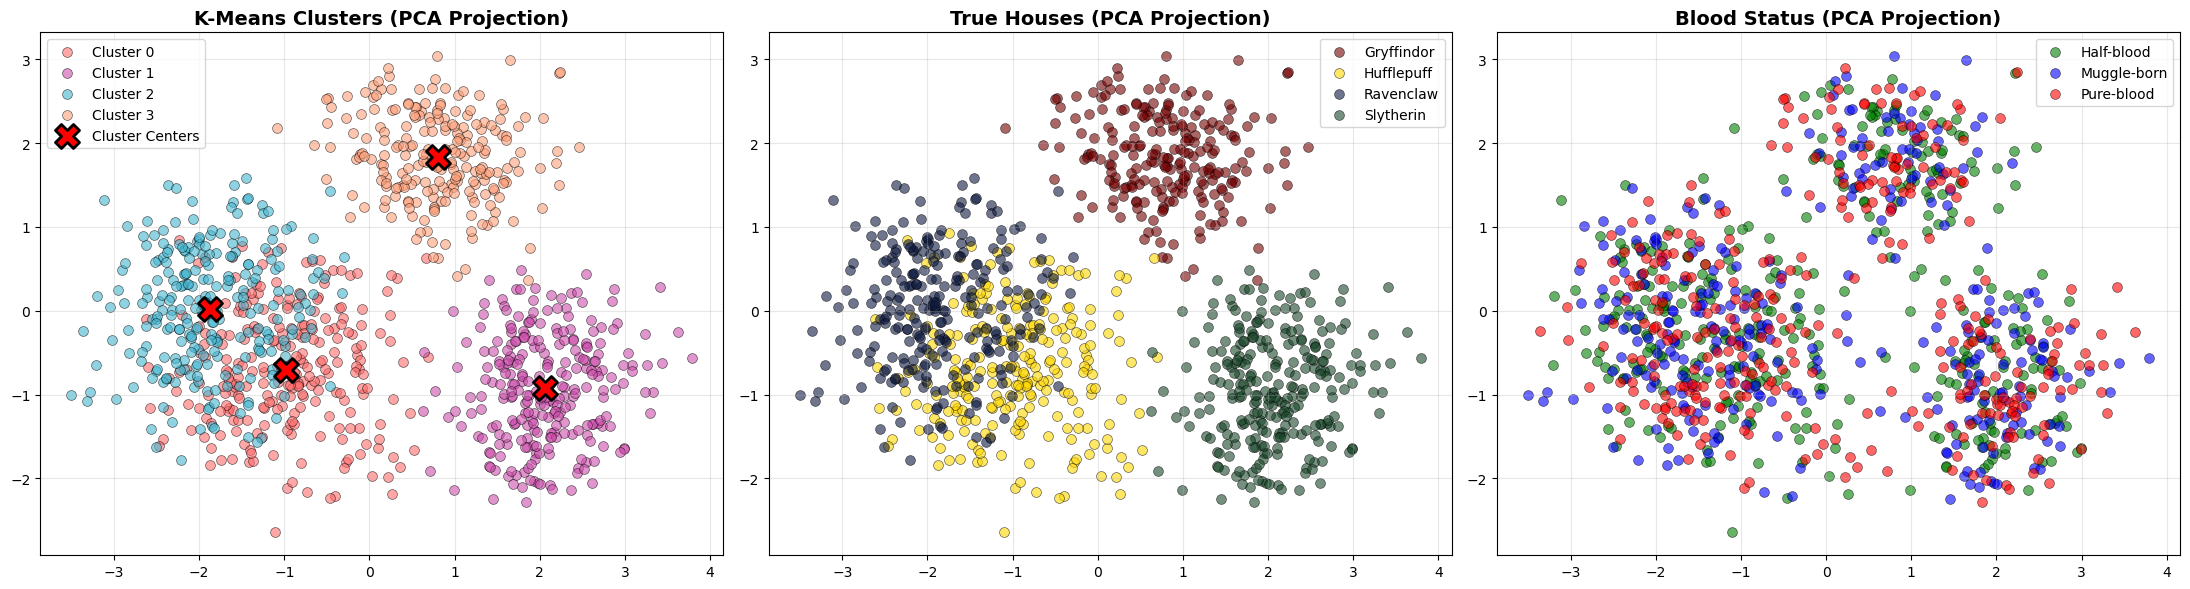

In [12]:
# Apply PCA to reduce the dimensions of clusters to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Define colors for clusters, houses, and blood status
cluster_colors = ['#FF6B6B', "#CD4EAD", '#45B7D1', '#FFA07A']
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}

# Plot 1: Colored by Cluster
ax1 = axes[0]
for cluster in range(4):
    mask = clusters == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[cluster], 
               label=f'Cluster {cluster}',
               alpha=0.6, 
               s=50,
               edgecolors='black',
               linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='red', 
           marker='X', 
           s=300, 
           edgecolors='black',
           linewidth=2,
           label='Cluster Centers',
           zorder=5)

# ax1.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
# ax1.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax1.set_title('K-Means Clusters (PCA Projection)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by True House
ax2 = axes[1]
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

# ax2.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
# ax2.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax2.set_title('True Houses (PCA Projection)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by Blood Status
ax3 = axes[2]
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

# ax3.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
# ax3.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax3.set_title('Blood Status (PCA Projection)', fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [31]:
df

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House,Blood Status Encoded,Cluster
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor,0,3
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw,1,2
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff,2,0
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor,2,3
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Half-blood,7,10,3,7,1,1,3,8,Ravenclaw,0,2
996,Pure-blood,7,3,2,7,8,6,7,7,Slytherin,2,1
997,Half-blood,5,10,5,3,3,5,7,10,Ravenclaw,0,2
998,Half-blood,5,6,10,4,4,6,2,4,Hufflepuff,0,0


## Clustering datapoints to correspond more to the lore from a subjective viewpoint

### Seeing which attributes correlate with probability of being Slytherin


SLYTHERIN PROBABILITY ANALYSIS
Model trained. Classes: ['Gryffindor' 'Hufflepuff' 'Ravenclaw' 'Slytherin']

Creating probability plots...


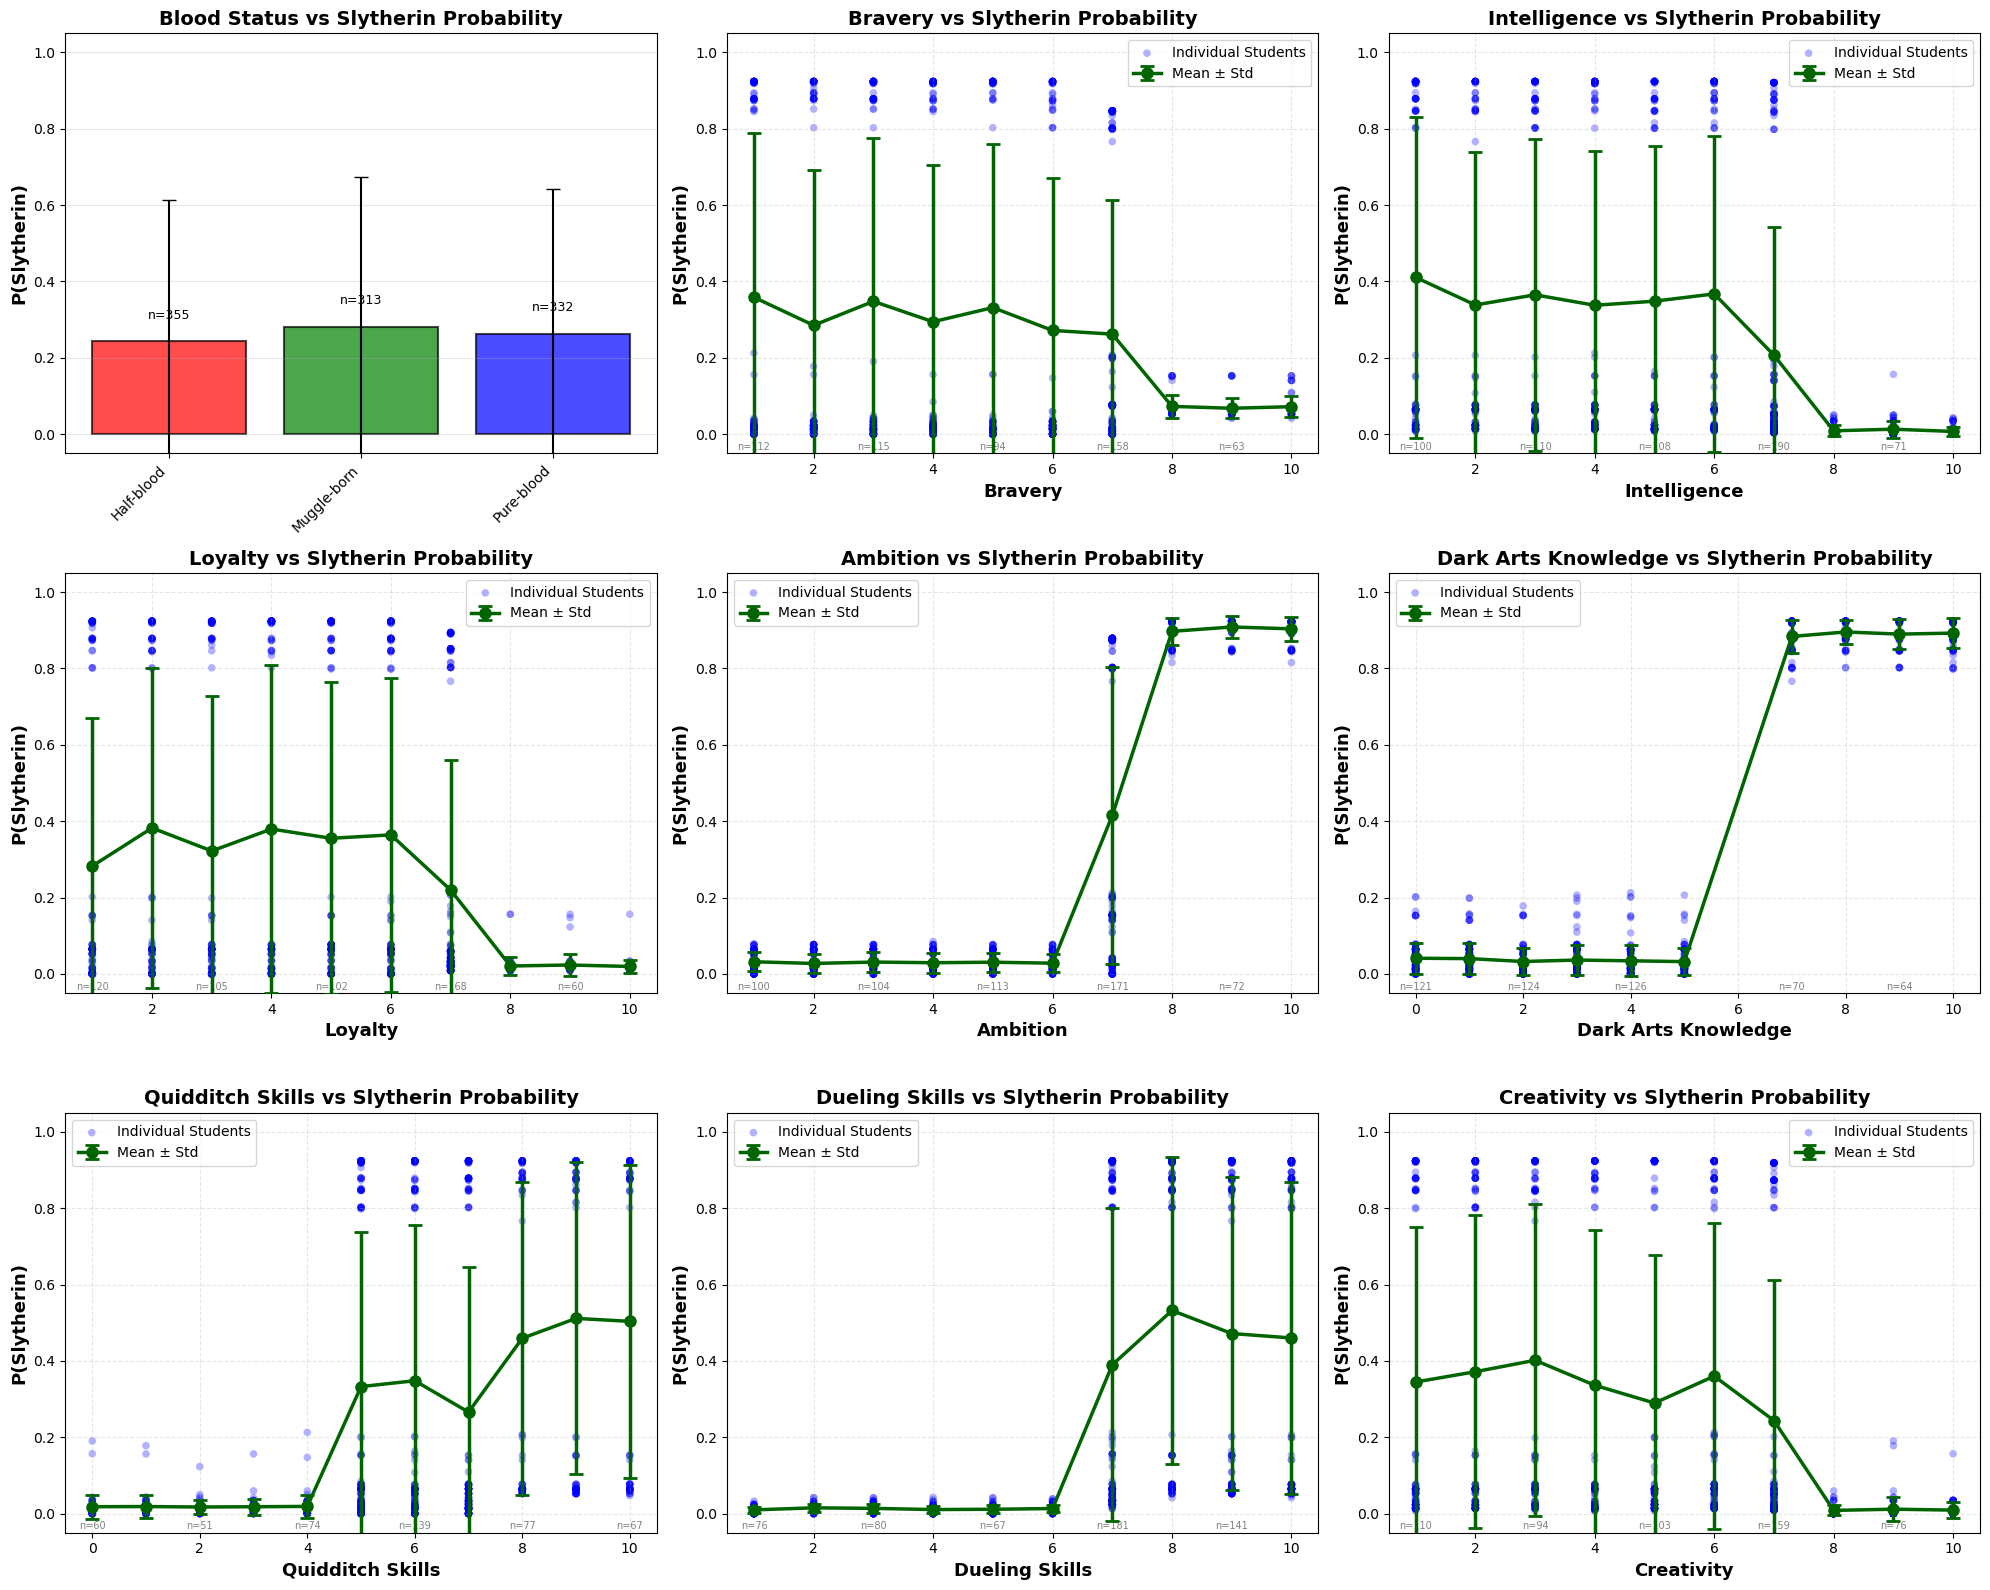

In [32]:
# TRAIN A MODEL TO GET PROBABILITIES
print("\n" + "="*60)
print("SLYTHERIN PROBABILITY ANALYSIS")
print("="*60)

# # Prepare features and target
# le = LabelEncoder()
# df['Blood Status Encoded'] = le.fit_transform(df['Blood Status'])

# feature_cols_prob = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
#                      'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
#                      'Dueling Skills', 'Creativity']

# X_prob = df[feature_cols_prob].values
# y_prob = df['House'].values

# # Train a Random Forest to get probability estimates
# print("\nTraining Random Forest for probability estimation...")
# rf_prob = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=20)
# rf_prob.fit(X_prob, y_prob)

# Get predicted probabilities for all houses
probs = rf_clf.predict_proba(X)
house_names = rf_clf.classes_

# Get Slytherin probabilities
slytherin_idx = np.where(house_names == 'Slytherin')[0][0]
slytherin_probs = probs[:, slytherin_idx]

# Add to dataframe
df['Slytherin_Probability'] = slytherin_probs

print(f"Model trained. Classes: {house_names}")

# CREATE PLOTS FOR ALL FEATURES
print("\nCreating probability plots...")

features_to_plot = ['Blood Status', 'Bravery', 'Intelligence', 'Loyalty', 
                    'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                    'Dueling Skills', 'Creativity']
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # Handle Blood Status separately (categorical)
    if feature == 'Blood Status':
        blood_status_probs = df.groupby('Blood Status')['Slytherin_Probability'].agg(['mean', 'std', 'count'])
        
        blood_types = blood_status_probs.index
        means = blood_status_probs['mean'].values
        stds = blood_status_probs['std'].values
        counts = blood_status_probs['count'].values
        
        x_pos = np.arange(len(blood_types))
        bars = ax.bar(x_pos, means, yerr=stds, capsize=5, 
                     color=['red', 'green', 'blue'], 
                     alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(blood_types, rotation=45, ha='right')
        ax.set_ylabel('P(Slytherin)', fontsize=13, fontweight='bold')
        ax.set_title(f'{feature} vs Slytherin Probability', 
                    fontsize=14, fontweight='bold')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add count labels
        for i, (bar, count) in enumerate(zip(bars, counts)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'n={count}', ha='center', va='bottom', fontsize=9)
        
        continue
    
    # Get feature values and corresponding Slytherin probabilities
    feature_values = df[feature].values
    probs_for_feature = df['Slytherin_Probability'].values
    
    # Calculate mean probability for each feature value
    unique_values = np.sort(df[feature].unique())
    mean_probs = []
    std_probs = []
    counts = []
    
    for val in unique_values:
        mask = feature_values == val
        mean_probs.append(probs_for_feature[mask].mean())
        std_probs.append(probs_for_feature[mask].std())
        counts.append(mask.sum())
    
    mean_probs = np.array(mean_probs)
    std_probs = np.array(std_probs)
    
    # Scatter plot: all individual data points
    ax.scatter(feature_values, probs_for_feature, 
              alpha=0.3, s=30, c='blue', edgecolors='none',
              label='Individual Students')
    
    # Line plot: mean probability with error bars
    ax.errorbar(unique_values, mean_probs, yerr=std_probs,
               fmt='o-', color='darkgreen', linewidth=2.5, 
               markersize=8, capsize=5, capthick=2,
               label='Mean ± Std', zorder=5)
    
    
    # Formatting
    ax.set_xlabel(feature, fontsize=13, fontweight='bold')
    ax.set_ylabel('P(Slytherin)', fontsize=13, fontweight='bold')
    ax.set_title(f'{feature} vs Slytherin Probability', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([-0.05, 1.05])
    ax.legend(loc='best', fontsize=10)
    
    # Add sample size annotations at the bottom
    for i, (val, count) in enumerate(zip(unique_values, counts)):
        if i % 2 == 0:  # Show every other to avoid crowding
            ax.text(val, -0.02, f'n={count}', 
                   ha='center', va='top', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

df.drop('Slytherin_Probability', axis=1, inplace=True)


### dynamic weights


DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Base Blood Status Weight: 1.0
Maximum Blood Status Weight: 500000001.0

Blood Status Weight Statistics:
  Min:    1.00
  Mean:   123638889.89
  Median: 50000001.00
  Max:    500000001.00

Weight Distribution by Ambition & Dark Arts Levels:
------------------------------------------------------------
  High   Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)
  High   Ambition + Medium Dark Arts: Avg Weight = 336678005.54 (n=294)
  High   Ambition + Low    Dark Arts: Avg Weight = 282274402.47 (n=362)
  Medium Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)
  Medium Ambition + Medium Dark Arts: Avg Weight = 275112234.45 (n=396)
  Medium Ambition + Low    Dark Arts: Avg Weight = 178159204.98 (n=670)
  Low    Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)

Applying dynamic weighted K-means with 4 clusters...

Dynamic Weighted Clustering Metrics:
  Silhouette Score: 0.3051
  Adjusted 

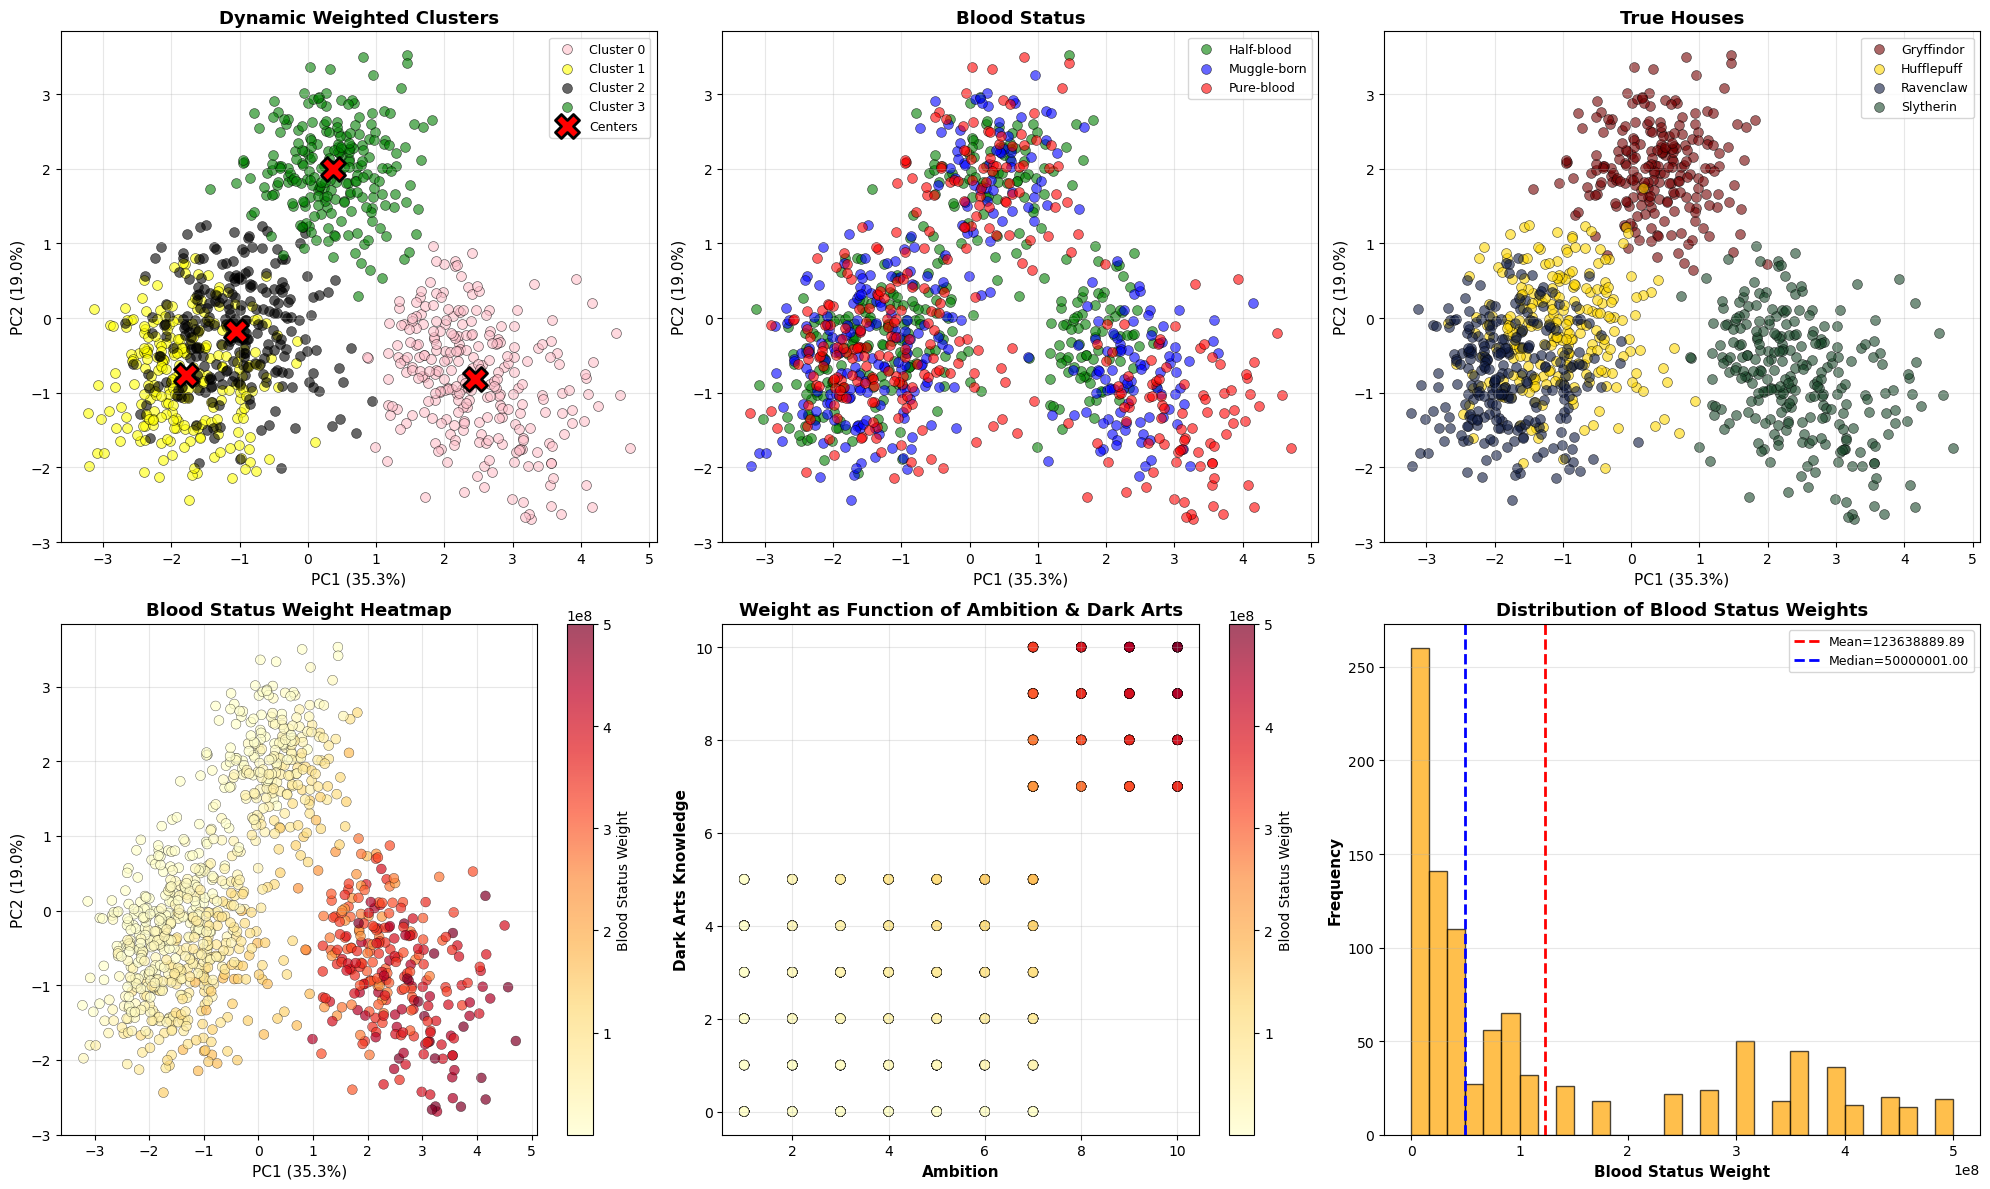


COMPARISON: STATIC vs DYNAMIC WEIGHTING

Dynamic Weighted Clustering (Weight: 1-500000001.0):
  ARI vs Houses: 0.9869
  Silhouette Score: 0.3051

------------------------------------------------------------
INTERPRETATION:
------------------------------------------------------------
Dynamic weighting means:
  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status matters MORE
  • Students with LOW Ambition + LOW Dark Arts → Blood Status matters LESS
  • This simulates 'blood purity matters more to ambitious dark wizards'

Check the 'Weight as Function' plot to see how weights vary!


In [33]:
# HONORABLE MENTIONS 

# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)

# Prepare features
cluster_features_dynamic = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                            'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                            'Dueling Skills', 'Creativity']

X_dynamic = df[cluster_features_dynamic].values

# Extract all features
blood_status = X_dynamic[:, 0]
bravery = X_dynamic[:, 1]
intelligence = X_dynamic[:, 2]
loyalty = X_dynamic[:, 3]
ambition = X_dynamic[:, 4]
dark_arts = X_dynamic[:, 5]
quidditch = X_dynamic[:, 6]
dueling = X_dynamic[:, 7]
creativity = X_dynamic[:, 8]

# Normalize ALL attributes to [0, 1] range
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bravery_norm = normalize(bravery)
intelligence_norm = normalize(intelligence)
loyalty_norm = normalize(loyalty)
ambition_norm = normalize(ambition)
dark_arts_norm = normalize(dark_arts)
quidditch_norm = normalize(quidditch)
dueling_norm = normalize(dueling)
creativity_norm = normalize(creativity)

# Create dynamic weight for Blood Status based on Ambition and Dark Arts
# Weight formula: base_weight + scaling_factor * (ambition_norm * dark_arts_norm)
base_weight = 1.0  # Minimum weight
scaling_factor = 500000000.0  # Maximum additional weight
power = 2.5  # Exponent to amplify high values (makes the effect non-linear)


# Calculate per-instance blood status weight
# High ambition AND high dark arts → high blood status weight
#blood_status_weights = base_weight + scaling_factor * (ambition_norm * dark_arts_norm / ( 1+ bravery_norm * intelligence_norm * loyalty_norm * quidditch_norm * dueling_norm * creativity_norm))
blood_status_weights = base_weight + scaling_factor * (ambition_norm * dark_arts_norm)

print(f"\nBase Blood Status Weight: {base_weight}")
print(f"Maximum Blood Status Weight: {base_weight + scaling_factor}")
print(f"\nBlood Status Weight Statistics:")
print(f"  Min:    {blood_status_weights.min():.2f}")
print(f"  Mean:   {blood_status_weights.mean():.2f}")
print(f"  Median: {np.median(blood_status_weights):.2f}")
print(f"  Max:    {blood_status_weights.max():.2f}")

# Show distribution of weights
print(f"\nWeight Distribution by Ambition & Dark Arts Levels:")
print("-" * 60)
for amb_threshold, amb_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
    for dark_threshold, dark_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
        mask = (ambition >= amb_threshold) & (dark_arts >= dark_threshold)
        if mask.sum() > 0:
            avg_weight = blood_status_weights[mask].mean()
            count = mask.sum()
            print(f"  {amb_label:6s} Ambition + {dark_label:6s} Dark Arts: "
                  f"Avg Weight = {avg_weight:5.2f} (n={count:3d})")
        if amb_threshold == 0 or dark_threshold == 0:
            break
    if amb_threshold == 0:
        break

# Create weighted feature matrix
X_dynamic_weighted = X_dynamic.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_dynamic_weighted[:, 0] = X_dynamic[:, 0] * blood_status_weights

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means
print("\nApplying dynamic weighted K-means with 4 clusters...")
kmeans_dynamic = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)

# Calculate metrics
silhouette_dynamic = silhouette_score(X_dynamic_scaled, clusters_dynamic)
ari_dynamic = adjusted_rand_score(df['House'], clusters_dynamic)

print(f"\nDynamic Weighted Clustering Metrics:")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")
print(f"  Adjusted Rand Index (vs Houses): {ari_dynamic:.4f}")

# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights

# Show cluster distribution
print("\n" + "-"*60)
print("Dynamic Cluster Distribution:")
print("-"*60)
unique_clusters_d, cluster_counts_d = np.unique(clusters_dynamic, return_counts=True)
for cluster, count in zip(unique_clusters_d, cluster_counts_d):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Dynamic Clusters vs Blood Status
print("\n" + "-"*60)
print("Dynamic Cluster vs Blood Status:")
print("-"*60)
crosstab_blood_d = pd.crosstab(df['Dynamic_Cluster'], df['Blood Status'], margins=True)
print(crosstab_blood_d)

# Cross-tabulation: Dynamic Clusters vs Houses
print("\n" + "-"*60)
print("Dynamic Cluster vs House:")
print("-"*60)
crosstab_house_d = pd.crosstab(df['Dynamic_Cluster'], df['House'], margins=True)
print(crosstab_house_d)

# Analyze clusters with high blood status weight
print("\n" + "-"*60)
print("Average Blood Status Weight by Cluster:")
print("-"*60)
for cluster in sorted(df['Dynamic_Cluster'].unique()):
    cluster_mask = df['Dynamic_Cluster'] == cluster
    avg_weight = df.loc[cluster_mask, 'Blood_Status_Weight'].mean()
    avg_ambition = df.loc[cluster_mask, 'Ambition'].mean()
    avg_dark_arts = df.loc[cluster_mask, 'Dark Arts Knowledge'].mean()
    print(f"  Cluster {cluster}: Weight={avg_weight:5.2f}, "
          f"Ambition={avg_ambition:.2f}, Dark Arts={avg_dark_arts:.2f}")

# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['pink', 'yellow', 'black', 'green']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)

ax1.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('Dynamic Weighted Clusters', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax3.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Colored by Blood Status Weight (heatmap style)
ax4 = plt.subplot(2, 3, 4)
scatter = ax4.scatter(X_pca_dynamic[:, 0], X_pca_dynamic[:, 1],
                     c=blood_status_weights,
                     cmap='YlOrRd',
                     s=50,
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Blood Status Weight', fontsize=10)
ax4.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax4.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax4.set_title('Blood Status Weight Heatmap', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Ambition vs Dark Arts colored by Blood Status Weight
ax5 = plt.subplot(2, 3, 5)
scatter5 = ax5.scatter(ambition, dark_arts,
                      c=blood_status_weights,
                      cmap='YlOrRd',
                      s=50,
                      alpha=0.7,
                      edgecolors='black',
                      linewidth=0.3)
cbar5 = plt.colorbar(scatter5, ax=ax5)
cbar5.set_label('Blood Status Weight', fontsize=10)
ax5.set_xlabel('Ambition', fontsize=11, fontweight='bold')
ax5.set_ylabel('Dark Arts Knowledge', fontsize=11, fontweight='bold')
ax5.set_title('Weight as Function of Ambition & Dark Arts', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Weight distribution histogram
ax6 = plt.subplot(2, 3, 6)
ax6.hist(blood_status_weights, bins=30, color='orange', edgecolor='black', alpha=0.7)
ax6.axvline(blood_status_weights.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={blood_status_weights.mean():.2f}')
ax6.axvline(np.median(blood_status_weights), color='blue', linestyle='--', linewidth=2, label=f'Median={np.median(blood_status_weights):.2f}')
ax6.set_xlabel('Blood Status Weight', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6.set_title('Distribution of Blood Status Weights', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# COMPARISON
print("\n" + "="*60)
print("COMPARISON: STATIC vs DYNAMIC WEIGHTING")
print("="*60)

if 'Weighted_Cluster' in df.columns:
    print(f"\nStatic Weighted Clustering (Blood Status Weight: {blood_status_weight}x):")
    print(f"  ARI vs Houses: {ari_weighted:.4f}")
    print(f"  Silhouette Score: {silhouette_weighted:.4f}")

print(f"\nDynamic Weighted Clustering (Weight: 1-{base_weight + scaling_factor}):")
print(f"  ARI vs Houses: {ari_dynamic:.4f}")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")

print("\n" + "-"*60)
print("INTERPRETATION:")
print("-"*60)
print("Dynamic weighting means:")
print("  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status matters MORE")
print("  • Students with LOW Ambition + LOW Dark Arts → Blood Status matters LESS")
print("  • This simulates 'blood purity matters more to ambitious dark wizards'")
print("\nCheck the 'Weight as Function' plot to see how weights vary!")


DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Base Blood Status Weight: 1.0
Maximum Blood Status Weight: 500000001.0
Power Factor: 2.5

Blood Status Weight Statistics:
  Min:    1.00
  Mean:   123638889.89
  Median: 50000001.00
  Max:    500000001.00

Weight Distribution by Ambition & Dark Arts Levels:
------------------------------------------------------------
  High   Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)
  High   Ambition + Medium Dark Arts: Avg Weight = 336678005.54 (n=294)
  High   Ambition + Low    Dark Arts: Avg Weight = 282274402.47 (n=362)
  Medium Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)
  Medium Ambition + Medium Dark Arts: Avg Weight = 275112234.45 (n=396)
  Medium Ambition + Low    Dark Arts: Avg Weight = 178159204.98 (n=670)
  Low    Ambition + High   Dark Arts: Avg Weight = 356666667.67 (n=265)

Applying dynamic weighted K-means with 7 clusters...

Dynamic Weighted Clustering Metrics:
  Silhouette Score: 

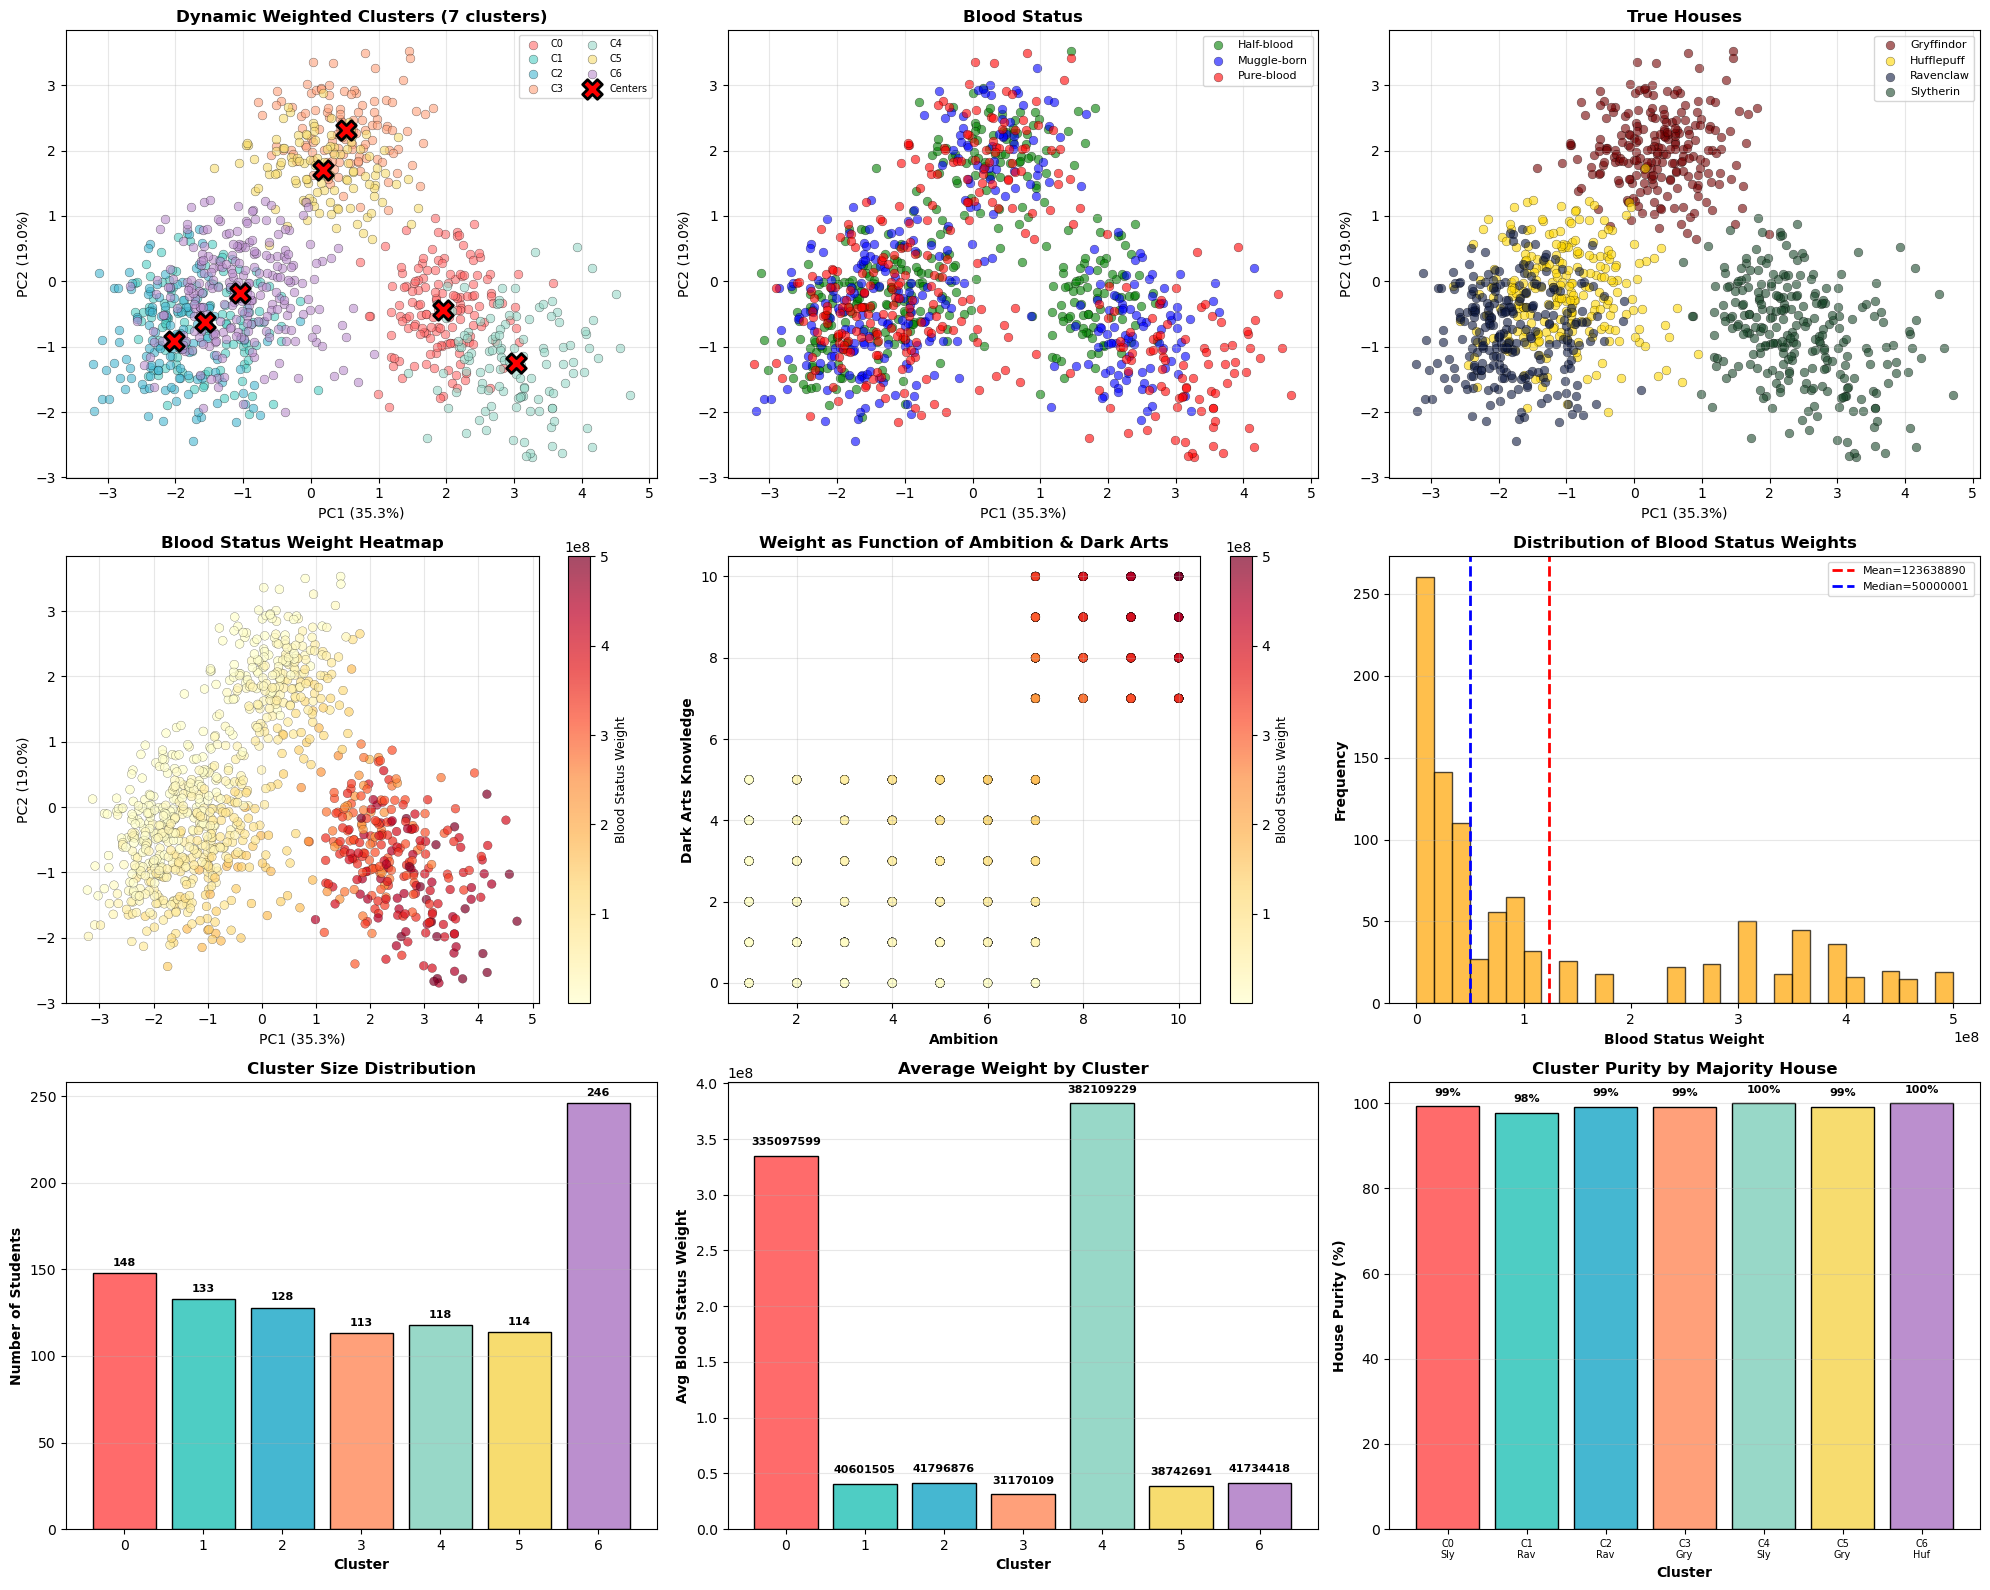


COMPARISON: STATIC vs DYNAMIC WEIGHTING

Dynamic Weighted Clustering with 7 clusters (Weight: 1-500000001):
  ARI vs Houses: 0.7000
  Silhouette Score: 0.1866

------------------------------------------------------------
INTERPRETATION:
------------------------------------------------------------
Dynamic weighting with 7 clusters:
  • Scaling factor: 500000000 (extremely high emphasis on blood status)
  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status weight MASSIVELY increases
  • 7 clusters allow for more nuanced groupings beyond the 4 houses
  • Check cluster-to-house mapping to see how clusters align with houses

Check the visualizations to understand cluster characteristics!


In [34]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)

# Prepare features
cluster_features_dynamic = ['Blood Status Encoded', 'Bravery', 'Intelligence', 'Loyalty', 
                            'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 
                            'Dueling Skills', 'Creativity']

X_dynamic = df[cluster_features_dynamic].values

# Extract all features
blood_status = X_dynamic[:, 0]
bravery = X_dynamic[:, 1]
intelligence = X_dynamic[:, 2]
loyalty = X_dynamic[:, 3]
ambition = X_dynamic[:, 4]
dark_arts = X_dynamic[:, 5]
quidditch = X_dynamic[:, 6]
dueling = X_dynamic[:, 7]
creativity = X_dynamic[:, 8]

# Normalize ALL attributes to [0, 1] range
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

blood_status_norm = normalize(blood_status)
bravery_norm = normalize(bravery)
intelligence_norm = normalize(intelligence)
loyalty_norm = normalize(loyalty)
ambition_norm = normalize(ambition)
dark_arts_norm = normalize(dark_arts)
quidditch_norm = normalize(quidditch)
dueling_norm = normalize(dueling)
creativity_norm = normalize(creativity)

# Create dynamic weight for Blood Status based on Ambition and Dark Arts
base_weight = 1.0  # Minimum weight
scaling_factor = 500000000.0  # Maximum additional weight
power = 2.5  # Exponent to amplify high values (makes the effect non-linear)

# Calculate per-instance blood status weight
blood_status_weights = base_weight + scaling_factor * (ambition_norm * dark_arts_norm)

print(f"\nBase Blood Status Weight: {base_weight}")
print(f"Maximum Blood Status Weight: {base_weight + scaling_factor}")
print(f"Power Factor: {power}")
print(f"\nBlood Status Weight Statistics:")
print(f"  Min:    {blood_status_weights.min():.2f}")
print(f"  Mean:   {blood_status_weights.mean():.2f}")
print(f"  Median: {np.median(blood_status_weights):.2f}")
print(f"  Max:    {blood_status_weights.max():.2f}")

# Show distribution of weights
print(f"\nWeight Distribution by Ambition & Dark Arts Levels:")
print("-" * 60)
for amb_threshold, amb_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
    for dark_threshold, dark_label in [(7, "High"), (4, "Medium"), (0, "Low")]:
        mask = (ambition >= amb_threshold) & (dark_arts >= dark_threshold)
        if mask.sum() > 0:
            avg_weight = blood_status_weights[mask].mean()
            count = mask.sum()
            print(f"  {amb_label:6s} Ambition + {dark_label:6s} Dark Arts: "
                  f"Avg Weight = {avg_weight:5.2f} (n={count:3d})")
        if amb_threshold == 0 or dark_threshold == 0:
            break
    if amb_threshold == 0:
        break

# Create weighted feature matrix using normalized values
X_dynamic_weighted = np.column_stack([
    blood_status_norm * blood_status_weights,
    bravery_norm,
    intelligence_norm,
    loyalty_norm,
    ambition_norm,
    dark_arts_norm,
    quidditch_norm,
    dueling_norm,
    creativity_norm
])

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means with 7 clusters
print("\nApplying dynamic weighted K-means with 7 clusters...")
kmeans_dynamic = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)

# Calculate metrics
silhouette_dynamic = silhouette_score(X_dynamic_scaled, clusters_dynamic)
ari_dynamic = adjusted_rand_score(df['House'], clusters_dynamic)

print(f"\nDynamic Weighted Clustering Metrics:")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")
print(f"  Adjusted Rand Index (vs Houses): {ari_dynamic:.4f}")

# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights

# Show cluster distribution
print("\n" + "-"*60)
print("Dynamic Cluster Distribution:")
print("-"*60)
unique_clusters_d, cluster_counts_d = np.unique(clusters_dynamic, return_counts=True)
for cluster, count in zip(unique_clusters_d, cluster_counts_d):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Dynamic Clusters vs Blood Status
print("\n" + "-"*60)
print("Dynamic Cluster vs Blood Status:")
print("-"*60)
crosstab_blood_d = pd.crosstab(df['Dynamic_Cluster'], df['Blood Status'], margins=True)
print(crosstab_blood_d)

# Cross-tabulation: Dynamic Clusters vs Houses
print("\n" + "-"*60)
print("Dynamic Cluster vs House:")
print("-"*60)
crosstab_house_d = pd.crosstab(df['Dynamic_Cluster'], df['House'], margins=True)
print(crosstab_house_d)

# Cluster-to-House mapping
print("\n" + "-"*60)
print("Cluster-to-House Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Dynamic_Cluster'].unique()):
    house_counts = df[df['Dynamic_Cluster'] == cluster]['House'].value_counts()
    majority_house = house_counts.index[0]
    majority_count = house_counts.iloc[0]
    total = len(df[df['Dynamic_Cluster'] == cluster])
    print(f"  Cluster {cluster} → {majority_house:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# Analyze clusters with high blood status weight
print("\n" + "-"*60)
print("Average Traits by Cluster:")
print("-"*60)
for cluster in sorted(df['Dynamic_Cluster'].unique()):
    cluster_mask = df['Dynamic_Cluster'] == cluster
    avg_weight = df.loc[cluster_mask, 'Blood_Status_Weight'].mean()
    avg_ambition = df.loc[cluster_mask, 'Ambition'].mean()
    avg_dark_arts = df.loc[cluster_mask, 'Dark Arts Knowledge'].mean()
    avg_bravery = df.loc[cluster_mask, 'Bravery'].mean()
    avg_loyalty = df.loc[cluster_mask, 'Loyalty'].mean()
    print(f"  Cluster {cluster}: Weight={avg_weight:8.2f}, Amb={avg_ambition:.1f}, "
          f"Dark={avg_dark_arts:.1f}, Brav={avg_bravery:.1f}, Loyal={avg_loyalty:.1f}")

# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 16))

# Define colors for 7 clusters
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(3, 3, 1)
for cluster in range(7):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'C{cluster}',
               alpha=0.6,
               s=40,
               edgecolors='black',
               linewidth=0.3)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=200,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)

ax1.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax1.set_title('Dynamic Weighted Clusters (7 clusters)', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=7, ncol=2)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(3, 3, 2)
for blood_status_label in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status_label
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status_label],
               label=blood_status_label,
               alpha=0.6,
               s=40,
               edgecolors='black',
               linewidth=0.3)

ax2.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax2.set_title('Blood Status', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(3, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=40,
               edgecolors='black',
               linewidth=0.3)

ax3.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax3.set_title('True Houses', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)

# Plot 4: Colored by Blood Status Weight (heatmap style)
ax4 = plt.subplot(3, 3, 4)
scatter = ax4.scatter(X_pca_dynamic[:, 0], X_pca_dynamic[:, 1],
                     c=blood_status_weights,
                     cmap='YlOrRd',
                     s=40,
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=0.2)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Blood Status Weight', fontsize=9)
ax4.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax4.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax4.set_title('Blood Status Weight Heatmap', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Ambition vs Dark Arts colored by Blood Status Weight
ax5 = plt.subplot(3, 3, 5)
scatter5 = ax5.scatter(ambition, dark_arts,
                      c=blood_status_weights,
                      cmap='YlOrRd',
                      s=40,
                      alpha=0.7,
                      edgecolors='black',
                      linewidth=0.2)
cbar5 = plt.colorbar(scatter5, ax=ax5)
cbar5.set_label('Blood Status Weight', fontsize=9)
ax5.set_xlabel('Ambition', fontsize=10, fontweight='bold')
ax5.set_ylabel('Dark Arts Knowledge', fontsize=10, fontweight='bold')
ax5.set_title('Weight as Function of Ambition & Dark Arts', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Weight distribution histogram
ax6 = plt.subplot(3, 3, 6)
ax6.hist(blood_status_weights, bins=30, color='orange', edgecolor='black', alpha=0.7)
ax6.axvline(blood_status_weights.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean={blood_status_weights.mean():.0f}')
ax6.axvline(np.median(blood_status_weights), color='blue', linestyle='--', linewidth=2, 
            label=f'Median={np.median(blood_status_weights):.0f}')
ax6.set_xlabel('Blood Status Weight', fontsize=10, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax6.set_title('Distribution of Blood Status Weights', fontsize=12, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3, axis='y')

# Plot 7: Cluster sizes
ax7 = plt.subplot(3, 3, 7)
cluster_nums = sorted(df['Dynamic_Cluster'].unique())
cluster_sizes = [len(df[df['Dynamic_Cluster'] == c]) for c in cluster_nums]
bars = ax7.bar(cluster_nums, cluster_sizes, color=cluster_colors, edgecolor='black', linewidth=1)
ax7.set_xlabel('Cluster', fontsize=10, fontweight='bold')
ax7.set_ylabel('Number of Students', fontsize=10, fontweight='bold')
ax7.set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
ax7.set_xticks(cluster_nums)
ax7.grid(True, alpha=0.3, axis='y')
for bar, size in zip(bars, cluster_sizes):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{size}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 8: Average weight by cluster
ax8 = plt.subplot(3, 3, 8)
avg_weights = [df[df['Dynamic_Cluster'] == c]['Blood_Status_Weight'].mean() for c in cluster_nums]
bars = ax8.bar(cluster_nums, avg_weights, color=cluster_colors, edgecolor='black', linewidth=1)
ax8.set_xlabel('Cluster', fontsize=10, fontweight='bold')
ax8.set_ylabel('Avg Blood Status Weight', fontsize=10, fontweight='bold')
ax8.set_title('Average Weight by Cluster', fontsize=12, fontweight='bold')
ax8.set_xticks(cluster_nums)
ax8.grid(True, alpha=0.3, axis='y')
for bar, weight in zip(bars, avg_weights):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_weights)*0.02,
            f'{weight:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 9: Cluster purity by house
ax9 = plt.subplot(3, 3, 9)
cluster_purity = []
cluster_labels_plot = []
for cluster in cluster_nums:
    cluster_mask = df['Dynamic_Cluster'] == cluster
    house_counts = df[cluster_mask]['House'].value_counts()
    purity = house_counts.iloc[0] / house_counts.sum() * 100
    cluster_purity.append(purity)
    cluster_labels_plot.append(f"C{cluster}\n{house_counts.index[0][:3]}")

bars = ax9.bar(range(len(cluster_nums)), cluster_purity, color=cluster_colors, 
               edgecolor='black', linewidth=1)
ax9.set_xlabel('Cluster', fontsize=10, fontweight='bold')
ax9.set_ylabel('House Purity (%)', fontsize=10, fontweight='bold')
ax9.set_title('Cluster Purity by Majority House', fontsize=12, fontweight='bold')
ax9.set_xticks(range(len(cluster_nums)))
ax9.set_xticklabels(cluster_labels_plot, fontsize=7)
ax9.set_ylim([0, 105])
ax9.grid(True, alpha=0.3, axis='y')
for i, (bar, purity) in enumerate(zip(bars, cluster_purity)):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{purity:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# COMPARISON
print("\n" + "="*60)
print("COMPARISON: STATIC vs DYNAMIC WEIGHTING")
print("="*60)

if 'Weighted_Cluster' in df.columns:
    print(f"\nStatic Weighted Clustering (Blood Status Weight: {blood_status_weight}x):")
    print(f"  ARI vs Houses: {ari_weighted:.4f}")
    print(f"  Silhouette Score: {silhouette_weighted:.4f}")

print(f"\nDynamic Weighted Clustering with 7 clusters (Weight: 1-{base_weight + scaling_factor:.0f}):")
print(f"  ARI vs Houses: {ari_dynamic:.4f}")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")

print("\n" + "-"*60)
print("INTERPRETATION:")
print("-"*60)
print("Dynamic weighting with 7 clusters:")
print(f"  • Scaling factor: {scaling_factor:.0f} (extremely high emphasis on blood status)")
print("  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status weight MASSIVELY increases")
print("  • 7 clusters allow for more nuanced groupings beyond the 4 houses")
print("  • Check cluster-to-house mapping to see how clusters align with houses")
print("\nCheck the visualizations to understand cluster characteristics!")

### feature engineering 'prejudice' on original dataset

In [13]:
# SLYTHERIN PREJUDICE FEATURE ENGINEERING
def calculate_prejudice_factor(row):
    """
    Calculate prejudice factor based on House and Blood Status only for the Slytherin house.
    
    """
    # define prejudice factors
    if row['House'] == 'Slytherin':
        if row['Blood Status'] == 'Pure-blood':
            return 1.0
        elif row['Blood Status'] == 'Half-blood':
            return 0.7
        elif row['Blood Status'] == 'Muggle-born':
            return 0.5
    return 1.0 # No prejudice for other houses

# Apply the prejudice factor and create new columns
prejudice_factor = df.apply(calculate_prejudice_factor, axis=1)
df['slytherin_prejudice_ambition'] = df['Ambition'] * prejudice_factor
df['slytherin_prejudice_dark_arts'] = df['Dark Arts Knowledge'] * prejudice_factor

df = df[[col for col in df.columns if col != 'House'] + ['House']] # reorder columns


In [61]:
df

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,Blood Status Encoded,slytherin_prejudice_ambition,slytherin_prejudice_dark_arts,House
0,Half-blood,9,4,7,5,0,8,8,7,0,5.0,0.0,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,1,7.0,5.0,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,2,7.0,1.0,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,2,4.0,1.0,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,1,3.0,3.0,Ravenclaw
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Half-blood,7,10,3,7,1,1,3,8,0,7.0,1.0,Ravenclaw
996,Pure-blood,7,3,2,7,8,6,7,7,2,7.0,8.0,Slytherin
997,Half-blood,5,10,5,3,3,5,7,10,0,3.0,3.0,Ravenclaw
998,Half-blood,5,6,10,4,4,6,2,4,0,4.0,4.0,Hufflepuff



K-MEANS CLUSTERING (UNSUPERVISED)

Features used for clustering:
  - Bravery
  - Intelligence
  - Loyalty
  - slytherin_prejudice_ambition
  - slytherin_prejudice_dark_arts
  - Quidditch Skills
  - Dueling Skills
  - Creativity
  - Blood Status Encoded

Applying K-means with 4 clusters...

Silhouette Score: 0.2273 (higher is better, range: -1 to 1)
Adjusted Rand Index: 0.8845 (measures similarity to true houses, range: -1 to 1)

------------------------------------------------------------
Cluster Distribution:
------------------------------------------------------------
  Cluster 0: 267 students (26.7%)
  Cluster 1: 260 students (26.0%)
  Cluster 2: 251 students (25.1%)
  Cluster 3: 222 students (22.2%)

------------------------------------------------------------
Cluster vs House Cross-tabulation:
------------------------------------------------------------
House              Gryffindor  Hufflepuff  Ravenclaw  Slytherin   All
Cluster_prejudice                                         

/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_7714/2772987311.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster_prejudice'] = clusters


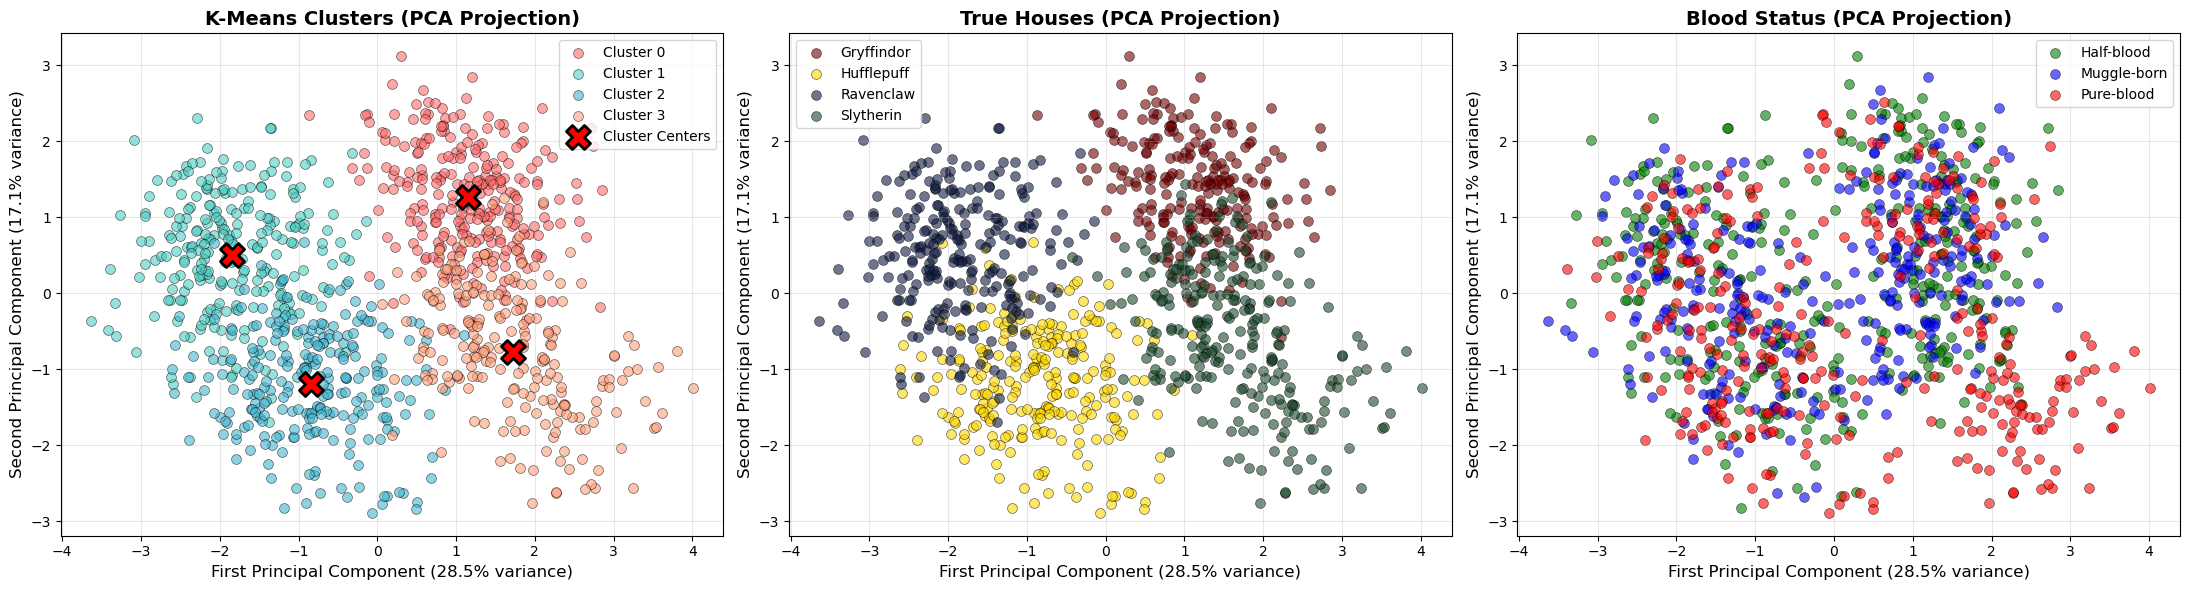

In [14]:
# มีทำไม
# K-MEANS CLUSTERING
print("\n" + "="*60)
print("K-MEANS CLUSTERING (UNSUPERVISED)")
print("="*60)

# Prepare features for clustering (only numerical attributes, no Blood Status)
cluster_features = ['Bravery', 'Intelligence', 'Loyalty', 'slytherin_prejudice_ambition', 
                    'slytherin_prejudice_dark_arts', 'Quidditch Skills', 'Dueling Skills', 'Creativity', 'Blood Status Encoded']

X_cluster = df[cluster_features].values

# Standardize features (important for K-means)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("\nFeatures used for clustering:")
for feat in cluster_features:
    print(f"  - {feat}")

# Apply K-means with 4 clusters (for 4 houses)
print("\nApplying K-means with 4 clusters...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to dataframe
df['Cluster_prejudice'] = clusters

# Calculate clustering metrics
silhouette = silhouette_score(X_cluster_scaled, clusters)
ari = adjusted_rand_score(df['House'], clusters)

print(f"\nSilhouette Score: {silhouette:.4f} (higher is better, range: -1 to 1)")
print(f"Adjusted Rand Index: {ari:.4f} (measures similarity to true houses, range: -1 to 1)")

# Show cluster distribution
print("\n" + "-"*60)
print("Cluster Distribution:")
print("-"*60)
unique_clusters, cluster_counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique_clusters, cluster_counts):
    print(f"  Cluster {cluster}: {count:3d} students ({count/len(df)*100:.1f}%)")

# Cross-tabulation: Clusters vs Houses
print("\n" + "-"*60)
print("Cluster vs House Cross-tabulation:")
print("-"*60)
crosstab = pd.crosstab(df['Cluster_prejudice'], df['House'], margins=True)
print(crosstab)

# Find which cluster corresponds to which house (based on majority)
print("\n" + "-"*60)
print("Cluster-to-House Mapping (based on majority):")
print("-"*60)
for cluster in sorted(df['Cluster_prejudice'].unique()):
    house_counts = df[df['Cluster_prejudice'] == cluster]['House'].value_counts()
    majority_house = house_counts.index[0]
    majority_count = house_counts.iloc[0]
    total = len(df[df['Cluster_prejudice'] == cluster])
    print(f"  Cluster {cluster} → {majority_house:12s} ({majority_count}/{total} = {majority_count/total*100:.1f}%)")

# Show cluster centers (average traits per cluster)
print("\n" + "-"*60)
print("Cluster Centers (Average Traits):")
print("-"*60)
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\n{'Feature':20s}", end='')
for i in range(4):
    print(f"Cluster {i:1d}  ", end='')
print()
print("-" * 60)
for i, feat in enumerate(cluster_features):
    print(f"{feat:20s}", end='')
    for j in range(4):
        print(f"{cluster_centers_original[j,i]:10.2f}", end='')
    print()

# Interpretation
print("\n" + "-"*60)
print("Clustering Interpretation:")
print("-"*60)
print(f"K-means found natural groupings in the data with {silhouette:.2f} silhouette score.")
print(f"The Adjusted Rand Index of {ari:.2f} shows how well clusters match actual houses.")
print("(ARI=1: perfect match, ARI=0: random, ARI<0: worse than random)")
# Apply PCA to reduce to 2 dimensions for visualization
print("\n" + "="*60)
print("PCA VISUALIZATION OF CLUSTERS")
print("="*60)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Define colors for clusters, houses, and blood status
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}

# Plot 1: Colored by Cluster
ax1 = axes[0]
for cluster in range(4):
    mask = clusters == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=cluster_colors[cluster], 
               label=f'Cluster {cluster}',
               alpha=0.6, 
               s=50,
               edgecolors='black',
               linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='red', 
           marker='X', 
           s=300, 
           edgecolors='black',
           linewidth=2,
           label='Cluster Centers',
           zorder=5)

ax1.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax1.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax1.set_title('K-Means Clusters (PCA Projection)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by True House
ax2 = axes[1]
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax2.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax2.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax2.set_title('True Houses (PCA Projection)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by Blood Status
ax3 = axes[2]
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

ax3.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax3.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax3.set_title('Blood Status (PCA Projection)', fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [63]:
df

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,Blood Status Encoded,slytherin_prejudice_ambition,slytherin_prejudice_dark_arts,House,Cluster_prejudice
0,Half-blood,9,4,7,5,0,8,8,7,0,5.0,0.0,Gryffindor,0
1,Muggle-born,6,8,5,7,5,6,4,9,1,7.0,5.0,Ravenclaw,1
2,Pure-blood,1,4,7,7,1,4,4,6,2,7.0,1.0,Hufflepuff,2
3,Pure-blood,9,1,3,4,1,9,10,1,2,4.0,1.0,Gryffindor,0
4,Muggle-born,5,9,7,3,3,6,7,9,1,3.0,3.0,Ravenclaw,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Half-blood,7,10,3,7,1,1,3,8,0,7.0,1.0,Ravenclaw,1
996,Pure-blood,7,3,2,7,8,6,7,7,2,7.0,8.0,Slytherin,3
997,Half-blood,5,10,5,3,3,5,7,10,0,3.0,3.0,Ravenclaw,1
998,Half-blood,5,6,10,4,4,6,2,4,0,4.0,4.0,Hufflepuff,2


In [17]:
# Check for half-bloods or muggle-borns in cluster 1
cluster_1_non_pureblood = df[(df['Cluster_prejudice'] == 3) & (df['Blood Status'].isin(['Half-blood', 'Muggle-born']))]

print(f"Non-purebloods in Cluster 1: {len(cluster_1_non_pureblood)}")
print(f"  Half-bloods: {len(df[(df['Cluster_prejudice'] == 3) & (df['Blood Status'] == 'Half-blood')])}")
print(f"  Muggle-borns: {len(df[(df['Cluster_prejudice'] == 3) & (df['Blood Status'] == 'Muggle-born')])}")

# Show the breakdown
print("\nCluster 1 Blood Status breakdown:")
print(df[df['Cluster_prejudice'] == 3]['Blood Status'].value_counts())

Non-purebloods in Cluster 1: 132
  Half-bloods: 82
  Muggle-borns: 50

Cluster 1 Blood Status breakdown:
Blood Status
Pure-blood     90
Half-blood     82
Muggle-born    50
Name: count, dtype: int64



DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Applying dynamic weighted K-means with 4 clusters...

Dynamic Weighted Clustering Metrics:
  Silhouette Score: 0.2458

VISUALIZING DYNAMIC WEIGHTED CLUSTERS


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_7714/1636391133.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dynamic_Cluster'] = clusters_dynamic
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_7714/1636391133.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Blood_Status_Weight'] = blood_status_weights


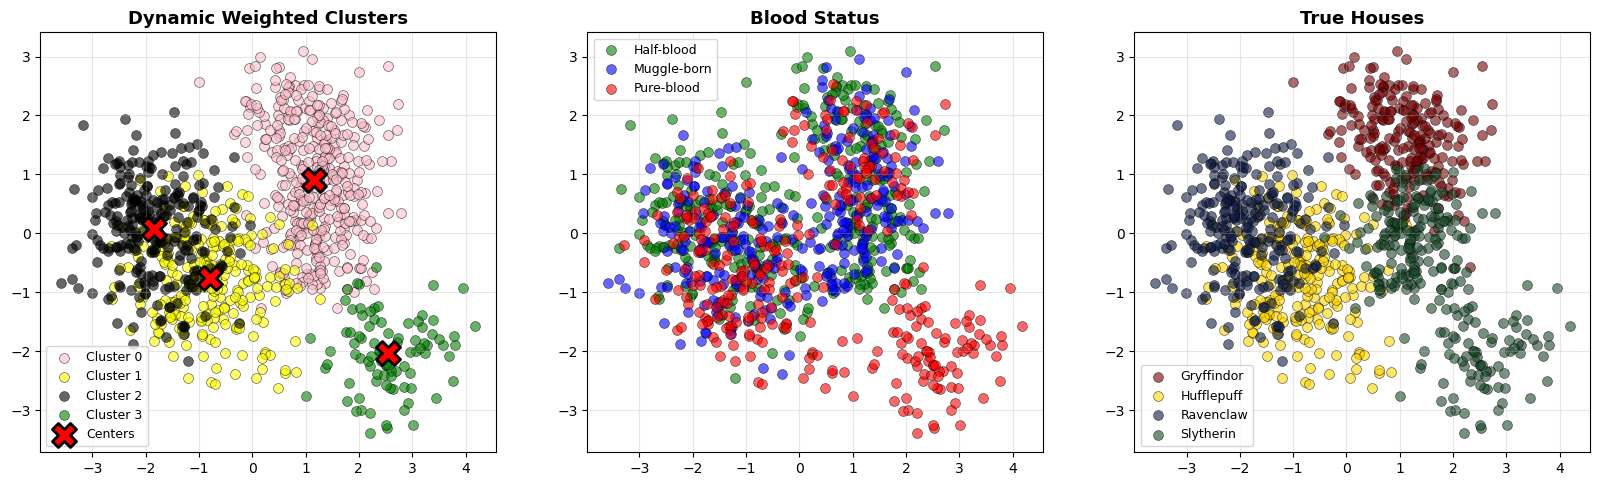

In [18]:
# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)


# Prepare features
cluster_features_dynamic = ['Blood Status Encoded','Bravery', 'Intelligence', 'Loyalty', 'slytherin_prejudice_ambition', 
                    'slytherin_prejudice_dark_arts', 'Quidditch Skills', 'Dueling Skills', 'Creativity']


X_dynamic = df[cluster_features_dynamic].values

# Extract Slytherin prejudice features
slytherin_prejudice_ambition = X_dynamic[:, 4]
slytherin_prejudice_dark_arts = X_dynamic[:, 5]


# Normalize these attributes to [0, 1] range
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

slytherin_prejudice_ambition_norm = normalize(slytherin_prejudice_ambition)
slytherin_prejudice_dark_arts_norm = normalize(slytherin_prejudice_dark_arts)


# Create dynamic weight for Blood Status based on Ambition and Dark Arts
base_weight = 1.0  # normal weight before scaling
scaling_factor = 0.44  # Maximum additional weight


# Calculate per-instance blood status weight
# Increasing the value of 'blood status weight' if character has high weighted ambition and  weighted dark arts knowledge
blood_status_weights = base_weight + scaling_factor * (slytherin_prejudice_ambition_norm * slytherin_prejudice_dark_arts_norm)


# Create weighted feature matrix
X_dynamic_weighted = X_dynamic.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_dynamic_weighted[:, 0] = X_dynamic[:, 0] * blood_status_weights

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means
print("\nApplying dynamic weighted K-means with 4 clusters...")
kmeans_dynamic = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)

# Calculate metrics
silhouette_dynamic = silhouette_score(X_dynamic_scaled, clusters_dynamic)
# ari_dynamic = adjusted_rand_score(df['House'], clusters_dynamic)

print(f"\nDynamic Weighted Clustering Metrics:")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")
#print(f"  Adjusted Rand Index (vs Houses): {ari_dynamic:.4f}")

# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights


# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['pink', 'yellow', 'black', 'green']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)

# ax1.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
# ax1.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('Dynamic Weighted Clusters', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

# ax2.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
# ax2.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

# ax3.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
# ax3.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)


# # COMPARISON
# print("\n" + "="*60)
# print("COMPARISON: STATIC vs DYNAMIC WEIGHTING")
# print("="*60)

# if 'Weighted_Cluster' in df.columns:
# #     print(f"\nStatic Weighted Clustering (Blood Status Weight: {blood_status_weight}x):")
# #     print(f"  ARI vs Houses: {ari_weighted:.4f}")
#     print(f"  Silhouette Score: {silhouette_weighted:.4f}")

# # print(f"\nDynamic Weighted Clustering (Weight: 1-{base_weight + scaling_factor}):")
# print(f"  ARI vs Houses: {ari_dynamic:.4f}")
# print(f"  Silhouette Score: {silhouette_dynamic:.4f}")

# print("\n" + "-"*60)
# print("INTERPRETATION:")
# print("-"*60)
# print("Dynamic weighting means:")
# print("  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status matters MORE")
# print("  • Students with LOW Ambition + LOW Dark Arts → Blood Status matters LESS")
# print("  • This simulates 'blood purity matters more to ambitious dark wizards'")
# print("\nCheck the 'Weight as Function' plot to see how weights vary!")

### เอาใหม่ๆ


DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)

Applying dynamic weighted K-means with 4 clusters...

Dynamic Weighted Clustering Metrics:
  Silhouette Score: 0.2288

VISUALIZING DYNAMIC WEIGHTED CLUSTERS


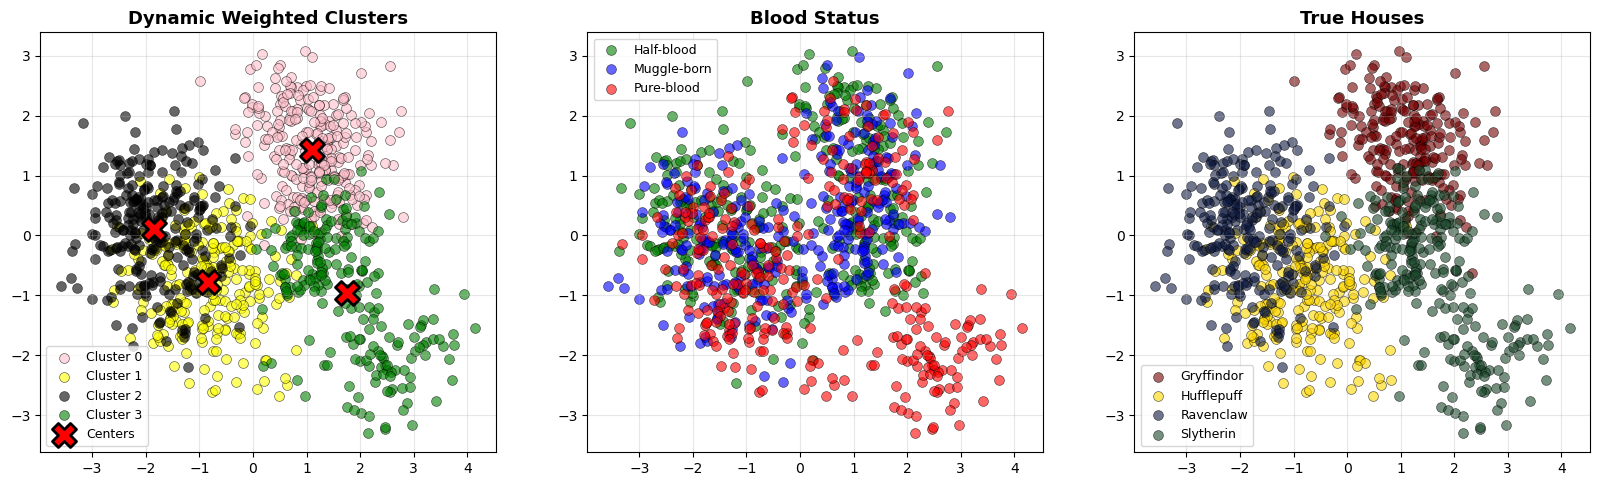

In [140]:
# DYNAMIC WEIGHTED K-MEANS CLUSTERING
print("\n" + "="*60)
print("DYNAMIC BLOOD STATUS WEIGHTING (based on Ambition & Dark Arts)")
print("="*60)


# Prepare features
cluster_features_dynamic = ['Blood Status Encoded','Bravery', 'Intelligence', 'Loyalty', 'slytherin_prejudice_ambition', 
                    'slytherin_prejudice_dark_arts', 'Quidditch Skills', 'Dueling Skills', 'Creativity']


X_dynamic = df[cluster_features_dynamic].values

# Extract Slytherin prejudice features
slytherin_prejudice_ambition = X_dynamic[:, 4]
slytherin_prejudice_dark_arts = X_dynamic[:, 5]
blood_status_pre = X_dynamic[:, 0]


# Normalize these attributes to [0, 1] range
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

slytherin_prejudice_ambition_norm = normalize(slytherin_prejudice_ambition)
slytherin_prejudice_dark_arts_norm = normalize(slytherin_prejudice_dark_arts)
blood_status_pre_norm = normalize(blood_status_pre)


# Create dynamic weight for Blood Status based on Ambition and Dark Arts
base_weight = 1.0  # normal weight before scaling
scaling_factor = 0.45  # Maximum additional weight
power = 2.5  # Exponent to amplify high values (makes the effect non-linear)


# Calculate per-instance blood status weight
# Increasing the value of 'blood status weight' if character has high weighted ambition and  weighted dark arts knowledge
blood_status_weights = base_weight + scaling_factor * (slytherin_prejudice_ambition_norm)


# Create weighted feature matrix
X_dynamic_weighted = X_dynamic.copy().astype(float)

# Apply dynamic weights to Blood Status column (index 0)
X_dynamic_weighted[:, 0] = X_dynamic[:, 0] * blood_status_weights

# Standardize the weighted features
scaler_dynamic = StandardScaler()
X_dynamic_scaled = scaler_dynamic.fit_transform(X_dynamic_weighted)

# Apply K-means
print("\nApplying dynamic weighted K-means with 4 clusters...")
kmeans_dynamic = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_dynamic = kmeans_dynamic.fit_predict(X_dynamic_scaled)

# Calculate metrics
silhouette_dynamic = silhouette_score(X_dynamic_scaled, clusters_dynamic)
# ari_dynamic = adjusted_rand_score(df['House'], clusters_dynamic)

print(f"\nDynamic Weighted Clustering Metrics:")
print(f"  Silhouette Score: {silhouette_dynamic:.4f}")
#print(f"  Adjusted Rand Index (vs Houses): {ari_dynamic:.4f}")

# Add dynamic cluster labels and weights to dataframe
df['Dynamic_Cluster'] = clusters_dynamic
df['Blood_Status_Weight'] = blood_status_weights


# VISUALIZATION
print("\n" + "="*60)
print("VISUALIZING DYNAMIC WEIGHTED CLUSTERS")
print("="*60)

# Apply PCA for visualization
pca_dynamic = PCA(n_components=2, random_state=42)
X_pca_dynamic = pca_dynamic.fit_transform(X_dynamic_scaled)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 12))

# Define colors
cluster_colors = ['pink', 'yellow', 'black', 'green']
blood_colors = {
    'Pure-blood': 'red',
    'Half-blood': 'green',
    'Muggle-born': 'blue'
}
house_colors = {
    'Gryffindor': '#740001',
    'Hufflepuff': '#FFD700',
    'Ravenclaw': '#0E1A40',
    'Slytherin': '#1A472A'
}

# Plot 1: Dynamic Clusters
ax1 = plt.subplot(2, 3, 1)
for cluster in range(4):
    mask = clusters_dynamic == cluster
    ax1.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=cluster_colors[cluster],
               label=f'Cluster {cluster}',
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

centers_pca_dynamic = pca_dynamic.transform(kmeans_dynamic.cluster_centers_)
ax1.scatter(centers_pca_dynamic[:, 0], centers_pca_dynamic[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidth=2,
           label='Centers',
           zorder=5)

# ax1.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
# ax1.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax1.set_title('Dynamic Weighted Clusters', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Colored by Blood Status
ax2 = plt.subplot(2, 3, 2)
for blood_status in sorted(df['Blood Status'].unique()):
    mask = df['Blood Status'] == blood_status
    ax2.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=blood_colors[blood_status],
               label=blood_status,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

# ax2.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
# ax2.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Blood Status', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Colored by House
ax3 = plt.subplot(2, 3, 3)
for house in sorted(df['House'].unique()):
    mask = df['House'] == house
    ax3.scatter(X_pca_dynamic[mask, 0], X_pca_dynamic[mask, 1],
               c=house_colors[house],
               label=house,
               alpha=0.6,
               s=50,
               edgecolors='black',
               linewidth=0.5)

# ax3.set_xlabel(f'PC1 ({pca_dynamic.explained_variance_ratio_[0]:.1%})', fontsize=11)
# ax3.set_ylabel(f'PC2 ({pca_dynamic.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax3.set_title('True Houses', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)


# # COMPARISON
# print("\n" + "="*60)
# print("COMPARISON: STATIC vs DYNAMIC WEIGHTING")
# print("="*60)

# if 'Weighted_Cluster' in df.columns:
# #     print(f"\nStatic Weighted Clustering (Blood Status Weight: {blood_status_weight}x):")
# #     print(f"  ARI vs Houses: {ari_weighted:.4f}")
#     print(f"  Silhouette Score: {silhouette_weighted:.4f}")

# # print(f"\nDynamic Weighted Clustering (Weight: 1-{base_weight + scaling_factor}):")
# print(f"  ARI vs Houses: {ari_dynamic:.4f}")
# print(f"  Silhouette Score: {silhouette_dynamic:.4f}")

# print("\n" + "-"*60)
# print("INTERPRETATION:")
# print("-"*60)
# print("Dynamic weighting means:")
# print("  • Students with HIGH Ambition + HIGH Dark Arts → Blood Status matters MORE")
# print("  • Students with LOW Ambition + LOW Dark Arts → Blood Status matters LESS")
# print("  • This simulates 'blood purity matters more to ambitious dark wizards'")
# print("\nCheck the 'Weight as Function' plot to see how weights vary!")

In [112]:
X_dynamic_weighted

array([[ 0.,  9.,  4., ...,  8.,  8.,  7.],
       [ 6.,  6.,  8., ...,  6.,  4.,  9.],
       [22.,  1.,  4., ...,  4.,  4.,  6.],
       ...,
       [ 0.,  5., 10., ...,  5.,  7., 10.],
       [ 0.,  5.,  6., ...,  6.,  2.,  4.],
       [ 0.,  7.,  1., ...,  0.,  3.,  3.]], shape=(1000, 9))

In [113]:
df

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,Blood Status Encoded,slytherin_prejudice_ambition,slytherin_prejudice_dark_arts,House,Cluster_prejudice,Dynamic_Cluster,Blood_Status_Weight
0,Half-blood,9,4,7,5,0,8,8,7,0,5.0,0.0,Gryffindor,0,1,1.0
1,Muggle-born,6,8,5,7,5,6,4,9,1,7.0,5.0,Ravenclaw,1,2,6.0
2,Pure-blood,1,4,7,7,1,4,4,6,2,7.0,1.0,Hufflepuff,2,0,11.0
3,Pure-blood,9,1,3,4,1,9,10,1,2,4.0,1.0,Gryffindor,0,1,11.0
4,Muggle-born,5,9,7,3,3,6,7,9,1,3.0,3.0,Ravenclaw,1,2,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Half-blood,7,10,3,7,1,1,3,8,0,7.0,1.0,Ravenclaw,1,2,1.0
996,Pure-blood,7,3,2,7,8,6,7,7,2,7.0,8.0,Slytherin,3,3,11.0
997,Half-blood,5,10,5,3,3,5,7,10,0,3.0,3.0,Ravenclaw,1,2,1.0
998,Half-blood,5,6,10,4,4,6,2,4,0,4.0,4.0,Hufflepuff,2,0,1.0


In [132]:
# Check for half-bloods or muggle-borns in cluster 1
cluster_1_non_pureblood = df[(df['Dynamic_Cluster'] == 2) & (df['Blood Status'].isin(['Half-blood', 'Muggle-born']))]

print(f"Non-purebloods in Cluster 1: {len(cluster_1_non_pureblood)}")
print(f"  Half-bloods: {len(df[(df['Dynamic_Cluster'] == 2) & (df['Blood Status'] == 'Half-blood')])}")
print(f"  Muggle-borns: {len(df[(df['Dynamic_Cluster'] == 2) & (df['Blood Status'] == 'Muggle-born')])}")

# Show the breakdown
print("\nCluster 1 Blood Status breakdown:")
print(df[df['Dynamic_Cluster'] == 2]['Blood Status'].value_counts())

Non-purebloods in Cluster 1: 0
  Half-bloods: 0
  Muggle-borns: 0

Cluster 1 Blood Status breakdown:
Blood Status
Pure-blood    89
Name: count, dtype: int64


In [141]:
# Check for half-bloods or muggle-borns in cluster 1
cluster_1_non_pureblood = df[(df['Dynamic_Cluster'] == 3) & (df['Blood Status'].isin(['Half-blood', 'Muggle-born']))]

print(f"Non-purebloods in Cluster 1: {len(cluster_1_non_pureblood)}")
print(f"  Half-bloods: {len(df[(df['Dynamic_Cluster'] == 3) & (df['Blood Status'] == 'Half-blood')])}")
print(f"  Muggle-borns: {len(df[(df['Dynamic_Cluster'] == 3) & (df['Blood Status'] == 'Muggle-born')])}")

# Show the breakdown
print("\nCluster 1 Blood Status breakdown:")
print(df[df['Dynamic_Cluster'] == 3]['Blood Status'].value_counts())

Non-purebloods in Cluster 1: 132
  Half-bloods: 82
  Muggle-borns: 50

Cluster 1 Blood Status breakdown:
Blood Status
Pure-blood     92
Half-blood     82
Muggle-born    50
Name: count, dtype: int64


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define attributes to plot (excluding cluster columns and non-numeric)
attributes = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 'slytherin_prejudice_ambition',
              'Dark Arts Knowledge', 'slytherin_prejudice_dark_arts', 'Quidditch Skills', 
              'Dueling Skills', 'Creativity','Blood_Status_Weight','Blood Status Encoded']

# Get unique clusters
clusters = sorted(df['Dynamic_Cluster'].unique())
n_clusters = len(clusters)

print("="*80)
print("MEAN VALUES BY CLUSTER")
print("="*80)
summary = df.groupby('Dynamic_Cluster')[attributes].mean().round(2)

from tabulate import tabulate
print(tabulate(summary, headers='keys', tablefmt='grid', floatfmt='.2f'))


MEAN VALUES BY CLUSTER
+-------------------+-----------+----------------+-----------+------------+--------------------------------+-----------------------+---------------------------------+--------------------+------------------+--------------+-----------------------+------------------------+
|   Dynamic_Cluster |   Bravery |   Intelligence |   Loyalty |   Ambition |   slytherin_prejudice_ambition |   Dark Arts Knowledge |   slytherin_prejudice_dark_arts |   Quidditch Skills |   Dueling Skills |   Creativity |   Blood_Status_Weight |   Blood Status Encoded |
+===================+===========+================+===========+============+================================+=======================+=================================+====================+==================+==============+=======================+========================+
|                 0 |      6.47 |           4.18 |      4.02 |       5.77 |                           4.30 |                  4.81 |                            3.35